# Lembar Kerja Data Science
# PEMETAAN PROFIL KEPRIBADIAN MAHASISWA PADA DATA OMNI TEST MELALUI LATENT PROFILE ANALYSIS (LPA) UNTUK REKOMENDASI INTERVENSI KESEHATAN MENTAL BERBASIS DATA

**Peneliti:** Dhifulloh Dhiya Ulhaq — 1202220139  
**Program Studi:** S1 Sistem Informasi, Fakultas Rekayasa Industri  
**Universitas Telkom, 2026**

**Framework:** CRISP-DM  
**Metode:** Gaussian Mixture Model (GMM) sebagai basis LPA  
**Data:** OMNI Personality Inventory (OMNI) — 42 Skala (25 Normal + 10 PD + 7 Faktor), 2 Validity Scales

* * *

**Tahapan:**
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment Preparation

---
# Setup & Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
sns.set_palette('Set2')

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


# 1. Business Understanding

## 1.1 Latar Belakang
Data OMNI dikumpulkan dari mahasiswa Universitas Telkom, namun belum dimanfaatkan secara optimal. Di sisi lain, analisis manual pada data tersebut (dengan 35 skala yang ada) tidak efisien dan tidak skalabel untuk populasi besar.

## 1.2 Rumusan Masalah
Bagaimana mengidentifikasi struktur profil kepribadian laten mahasiswa dari data
OMNI menggunakan LPA untuk mendukung rekomendasi intervensi kesehatan mental?

## 1.3 Tujuan Analitik
- Mengidentifikasi profil kepribadian laten menggunakan Latent Profile
  Analysis (LPA) berbasis Gaussian Mixture Model (GMM)
- Memetakan distribusi profil lintas demografis (fakultas, prodi, angkatan, gender)
- Menyediakan insight yang actionable untuk intervensi kesehatan mental

## 1.4 Kriteria Keberhasilan
- Entropy model ≥ 0.80 (klasifikasi cukup tegas)
- Setiap profil mencakup >5% populasi
- Profil dapat diinterpretasikan secara substantif oleh psikolog

* * *

# 2. Data Understanding

## 2.1 Load dan Eksplorasi Awal Data

In [ ]:
# Jika di Google Colab, upload file terlebih dahulu
from google.colab import files
files.upload()

df_raw = pd.read_csv('dataset_omni_dummy.csv')
df_raw.head(5)

Saving dataset_omni_dummy.csv to dataset_omni_dummy.csv


,Student_ID,Gender,Fakultas,Program_Studi,Angkatan,Val_VRIN,Val_CD,Sc_Aestheticism,Sc_Ambition,Sc_Anxiety,...,Sc_Avoidant,Sc_Dependent,Sc_ObsessiveCompulsive,Sc_Agreeableness,Sc_Conscientiousness,Sc_Extraversion,Sc_Narcissism,Sc_Neuroticism,Sc_Openness,Sc_SensationSeeking
0,ST0001,Laki-laki,FKS,Ilmu Komunikasi,2023,55.5,56.1,54.1,68.6,32.9,...,30.5,44.7,60.4,58.8,67.8,62.2,47.6,35.5,38.6,44.1
1,ST0002,Perempuan,FEB,Akuntansi,2021,47.3,56.9,65.2,42.2,79.1,...,60.6,59.8,49.4,30.5,34.1,25.8,60.5,71.7,49.8,48.1
2,ST0003,Perempuan,FIF,Informatika,2023,57.2,77.7,35.8,41.9,73.1,...,74.5,54.6,42.4,31.3,35.0,40.4,39.6,68.7,45.3,28.7
3,ST0004,Perempuan,FRI,Sistem Informasi,2024,44.4,40.6,54.6,53.1,50.4,...,48.3,35.1,34.4,49.4,37.5,73.4,56.2,53.7,44.4,73.2
4,ST0005,Perempuan,FRI,Teknik Industri,2024,59.5,54.8,64.5,66.0,27.2,...,23.7,40.1,52.6,74.5,50.2,50.7,51.4,33.6,66.2,44.8


**Interpretasi Eksplorasi Awal Data:**

Berdasarkan hasil pemuatan data awal dan inspeksi terhadap struktur dataset, dapat disimpulkan beberapa poin teknis berikut:
1. Dimensi dan Struktur Data: Dataset terdiri dari 1.250 observasi (baris) dan 49 kolom. Kolom tersebut terbagi menjadi 5 atribut identitas & demografi (Student_ID, Gender, Fakultas, Program_Studi, Angkatan), 2 atribut validitas (Val_VRIN, Val_CD), serta 42 skala kepribadian OMNI (25 Normal Scales, 10 Disorder Scales, dan 7 Factor Scales).
2. Cakupan Spektrum: Data mencakup dimensi kepribadian yang sangat komprehensif, merentang dari sifat umum (seperti Ambition dan Sociability) hingga deteksi patologi klinis (seperti Paranoid, Schizoid, dan Borderline).
3. Deteksi Awal Kualitas Data: Terdapat variasi skor yang sangat ekstrem antar mahasiswa. Sebagai contoh, pada skala Sc_Anxiety, terdapat rentang nilai yang sangat timpang (ST0001 skor 32.9 vs ST0002 skor 79.1). Lebih lanjut, sekilas pengecekan tipe data (dtypes) menunjukkan bahwa seluruh skala telah berformat numerik (float64), yang berarti data sudah siap untuk dianalisis secara matematis, namun memerlukan pembersihan intensif.
4. Indikator Validitas: Kehadiran kolom Val_VRIN dan Val_CD akan menjadi parameter filter utama. Skor ini digunakan pada tahap Data Preparation untuk membuang baris data responden yang terdeteksi mengisi secara asal-asalan (careless responding) atau sedang dalam tekanan mental akut (current distress).

Info tipe data

In [ ]:
df_raw.dtypes

,0
Student_ID,object
Gender,object
Fakultas,object
Program_Studi,object
Angkatan,int64
Val_VRIN,float64
Val_CD,float64
Sc_Aestheticism,float64
Sc_Ambition,float64
Sc_Anxiety,float64


**Interpretasi Pengecekan Tipe Data:**

Berdasarkan output `df_raw.dtypes`, dapat ditarik beberapa kesimpulan teknis mengenai kesiapan data:
1. **Data Identitas & Demografi**: Kolom seperti `Student_ID`, `Gender`, `Fakultas`, dan `Program_Studi` bertipe `object` (string). Ini merupakan variabel kategori yang akan digunakan untuk analisis deskriptif dan pemetaan profil di tahap akhir.
2. **Data Skala Kepribadian & Validitas**: Seluruh 42 skala kepribadian (prefiks `Sc_`) serta indikator validitas (`Val_VRIN`, `Val_CD`) telah terbaca sebagai `float64`. Hal ini sangat krusial karena algoritma *Latent Profile Analysis* (LPA) berbasis GMM memerlukan input numerik kontinu.
3. **Variabel Waktu**: Kolom `Angkatan` terbaca sebagai `int64`, yang tepat untuk merepresentasikan tahun akademik.
4. **Kesiapan Preprocessing**: Karena seluruh fitur utama sudah bertipe numerik, data tidak memerlukan konversi tipe data manual (seperti *label encoding* pada tahap awal) sebelum masuk ke proses standarisasi *Z-Score*.

## 2.2 Definisi Variabel

In [ ]:
# 25 Skala Kepribadian Normal
NORMAL_PERSONALITY_COLS = [
    'Sc_Aestheticism','Sc_Ambition','Sc_Anxiety','Sc_Assertiveness',
    'Sc_Conventionality','Sc_Depression','Sc_Dutifulness','Sc_Energy',
    'Sc_Excitement','Sc_Exhibitionism','Sc_Flexibility','Sc_Hostility',
    'Sc_Impulsiveness','Sc_Intellect','Sc_Irritability','Sc_Modesty',
    'Sc_Moodiness','Sc_Orderliness','Sc_SelfIndulgence','Sc_SelfReliance',
    'Sc_Sincerity','Sc_Sociability','Sc_Tolerance','Sc_Trustfulness','Sc_Warmth'
]

# 10 Skala Gangguan Kepribadian
PD_COLS = [
    'Sc_Paranoid','Sc_Schizoid','Sc_Schizotypal','Sc_Antisocial',
    'Sc_Borderline','Sc_Histrionic','Sc_Narcissistic','Sc_Avoidant',
    'Sc_Dependent','Sc_ObsessiveCompulsive'
]

# 7 Skala Faktor
FACTOR_COLS = [
    'Sc_Agreeableness','Sc_Conscientiousness','Sc_Extraversion',
    'Sc_Narcissism','Sc_Neuroticism','Sc_Openness','Sc_SensationSeeking'
]

# Gabungan: 42 skala total (25 + 10 + 7)
SCALE_COLS = NORMAL_PERSONALITY_COLS + PD_COLS + FACTOR_COLS

DEMOG_COLS = ['Student_ID', 'Gender', 'Fakultas', 'Program_Studi', 'Angkatan']
VALIDITY_COLS = ['Val_VRIN', 'Val_CD']

print(f"Jumlah skala kepribadian normal  : {len(NORMAL_PERSONALITY_COLS)}")
print(f"Jumlah skala gangguan kepribadian: {len(PD_COLS)}")
print(f"Jumlah skala faktor              : {len(FACTOR_COLS)}")
print(f"Total skala                      : {len(SCALE_COLS)}")
print(f"Kolom demografis                 : {DEMOG_COLS}")
print(f"Kolom validitas                  : {VALIDITY_COLS}")

Jumlah skala kepribadian normal  : 25
Jumlah skala gangguan kepribadian: 10
Jumlah skala faktor              : 7
Total skala                      : 42
Kolom demografis                 : ['Student_ID', 'Gender', 'Fakultas', 'Program_Studi', 'Angkatan']
Kolom validitas                  : ['Val_VRIN', 'Val_CD']


## 2.3 Statistik Deskriptif

Statistik deskriptif untuk kolom numerik (skala kepribadian)

In [ ]:
desc = df_raw[SCALE_COLS].describe().T
desc['range'] = desc['max'] - desc['min']
desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'range']]

,count,mean,std,min,25%,50%,75%,max,range
Sc_Aestheticism,1248.0,54.221234,10.347907,21.8,47.100,54.20,61.300,84.7,62.9
Sc_Ambition,1250.0,58.280880,16.265957,20.0,45.500,58.55,71.600,90.0,70.0
Sc_Anxiety,1249.0,48.613771,14.938974,-6.4,37.900,45.70,55.700,115.8,122.2
Sc_Assertiveness,1249.0,53.801201,12.499712,20.0,45.800,55.50,62.600,88.3,68.3
Sc_Conventionality,1249.0,50.903683,11.601609,20.1,43.000,50.90,59.200,90.0,69.9
Sc_Depression,1249.0,45.187030,14.777377,20.0,34.400,42.30,53.600,87.6,67.6
Sc_Dutifulness,1249.0,56.684868,15.256168,-3.7,45.200,57.60,68.500,90.0,93.7
Sc_Energy,1250.0,57.205040,15.475663,20.0,50.425,60.90,67.775,110.4,90.4
Sc_Excitement,1247.0,47.430874,15.326192,20.0,36.350,44.40,55.850,109.3,89.3
Sc_Exhibitionism,1248.0,52.959375,12.905697,-3.0,43.875,52.45,62.000,90.0,93.0


**Interpretasi Statistik Deskriptif:**

Berdasarkan ringkasan statistik deskriptif terhadap 42 skala kepribadian dan 2 skala validitas, ditemukan beberapa anomali data yang memperkuat urgensi dilakukannya Data Preparation:
1. **Tendensi Sentral (Mean & Median)**: Mayoritas skala kepribadian memiliki nilai rata-rata (mean) di kisaran 45 hingga 58. Angka ini sejalan dengan kaidah T-Score populasi normal, di mana skor rata-rata berada pada rentang Average (45–55).
2. **Kehadiran Outlier Ekstrem (Kritis)**: Secara teoritis, T-Score psikometri seharusnya berada di rentang 20 hingga 90. Namun, statistik menunjukkan adanya nilai negatif (misal: Sc_Anxiety dengan min -6.4, Sc_Paranoid min -7.9) serta nilai yang melampaui batas atas (misal: Sc_Orderliness max 118.0, Sc_Energy max 110.4). Anomali ini akan merusak penghitungan jarak matriks pada Gaussian Mixture Model (GMM), sehingga teknik clipping pada rentang [20, 90] mutlak harus dieksekusi di tahap selanjutnya.
3. **Indikasi Missing Values**: Jumlah observasi total adalah 1.250 mahasiswa (berdasarkan metrik count pada Val_VRIN). Namun, pada beberapa skala kepribadian (seperti Sc_Neuroticism dengan count 1.215, dan Sc_SensationSeeking dengan count 1.214), jumlahnya tidak mencapai 1.250. Hal ini memastikan adanya missing values (data kosong) yang harus ditangani (diimputasi atau di-drop).
4. **Distribusi Skor Validitas**: Nilai maksimal untuk Val_VRIN dan Val_CD mencapai 85.0. Mengingat ambang batas (Threshold) data tidak valid adalah T-Score $\ge$ 70, statistik ini membuktikan bahwa terdapat sejumlah sampel mahasiswa dengan profil tidak valid di dalam dataset yang harus disaring sebelum pemodelan klaster (clustering) dilakukan.

Statistik deskriptif untuk skor validitas

In [ ]:
df_raw[VALIDITY_COLS].describe()

,Val_VRIN,Val_CD
count,1250.00000,1250.000000
mean,52.73008,52.738080
std,10.00307,9.768856
min,40.00000,40.000000
25%,45.40000,45.800000
50%,51.20000,51.400000
75%,56.50000,56.600000
max,85.00000,85.000000


**Interpretasi Statistik Deskriptif Skor Validitas:**

Berdasarkan output statistik pada kolom `Val_VRIN` dan `Val_CD`, dapat ditarik beberapa kesimpulan penting terkait kualitas data:

1. **Kecenderungan Pusat (Mean & Median)**: Skor rata-rata (`mean`) untuk kedua skala validitas berada pada kisaran 52.7, dengan median (`50%`) sekitar 51.2 - 51.4. Hal ini menunjukkan bahwa secara kolektif, mayoritas mahasiswa mengisi kuesioner dengan tingkat konsistensi yang baik (berada di sekitar rata-rata populasi normal T=50).
2. **Variabilitas Data**: Standar deviasi (`std`) yang berada di angka ~10 menunjukkan sebaran data yang cukup lebar, yang berarti terdapat variasi yang signifikan dalam cara responden menjawab tes.
3. **Deteksi Data Tidak Valid (Outliers)**: Temuan paling krusial adalah nilai maksimum (`max`) yang mencapai **85.0** untuk kedua skala. Mengingat dalam psikometri OMNI, skor T-Score $\ge$ 70 pada VRIN (inkonsistensi) atau CD (distres akut) dianggap sebagai indikator profil tidak valid, maka statistik ini mengonfirmasi adanya kelompok responden yang datanya tidak layak masuk ke tahap pemodelan.
4. **Implikasi Preparation**: Tingginya nilai maksimum ini memberikan justifikasi kuat untuk melakukan prosedur filtering pada tahap *Data Preparation* guna menjaga reliabilitas model *Latent Profile Analysis*.

## 2.4 Pemeriksaan Kualitas Data

Cek missing values

In [ ]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_report = pd.DataFrame({
    'Jumlah Missing': missing,
})
missing_report = missing_report[missing_report['Jumlah Missing'] > 0]
if len(missing_report) > 0:
    print(f"\n⚠️ Terdapat {len(missing_report)} kolom dengan missing values:")
    print(missing_report)
    print(f"\nTotal missing values:               {df_raw.isnull().sum().sum()}")
else:
    print("✅ Tidak ada missing values.")


⚠️ Terdapat 41 kolom dengan missing values:
                        Jumlah Missing
Gender                               3
Fakultas                             1
Program_Studi                        1
Sc_Aestheticism                      2
Sc_Anxiety                           1
Sc_Assertiveness                     1
Sc_Conventionality                   1
Sc_Depression                        1
Sc_Dutifulness                       1
Sc_Excitement                        3
Sc_Exhibitionism                     2
Sc_Flexibility                       2
Sc_Hostility                         2
Sc_Impulsiveness                     2
Sc_Intellect                         3
Sc_Irritability                      1
Sc_Modesty                           3
Sc_Orderliness                       2
Sc_SelfIndulgence                    1
Sc_SelfReliance                      4
Sc_Sociability                       1
Sc_Tolerance                         2
Sc_Trustfulness                      2
Sc_Warmth          

Cek duplikasi data (Student_ID)

In [ ]:
n_dup = df_raw['Student_ID'].duplicated().sum()
if n_dup > 0:
    print(f"\n⚠️ Terdapat {n_dup} Student_ID duplikat.")
else:
    print("✅ Tidak ada duplikasi data (Student_ID unik).")


⚠️ Terdapat 12 Student_ID duplikat.


## 2.5 Visualisasi Distribusi Data

Distribusi Normal Scales

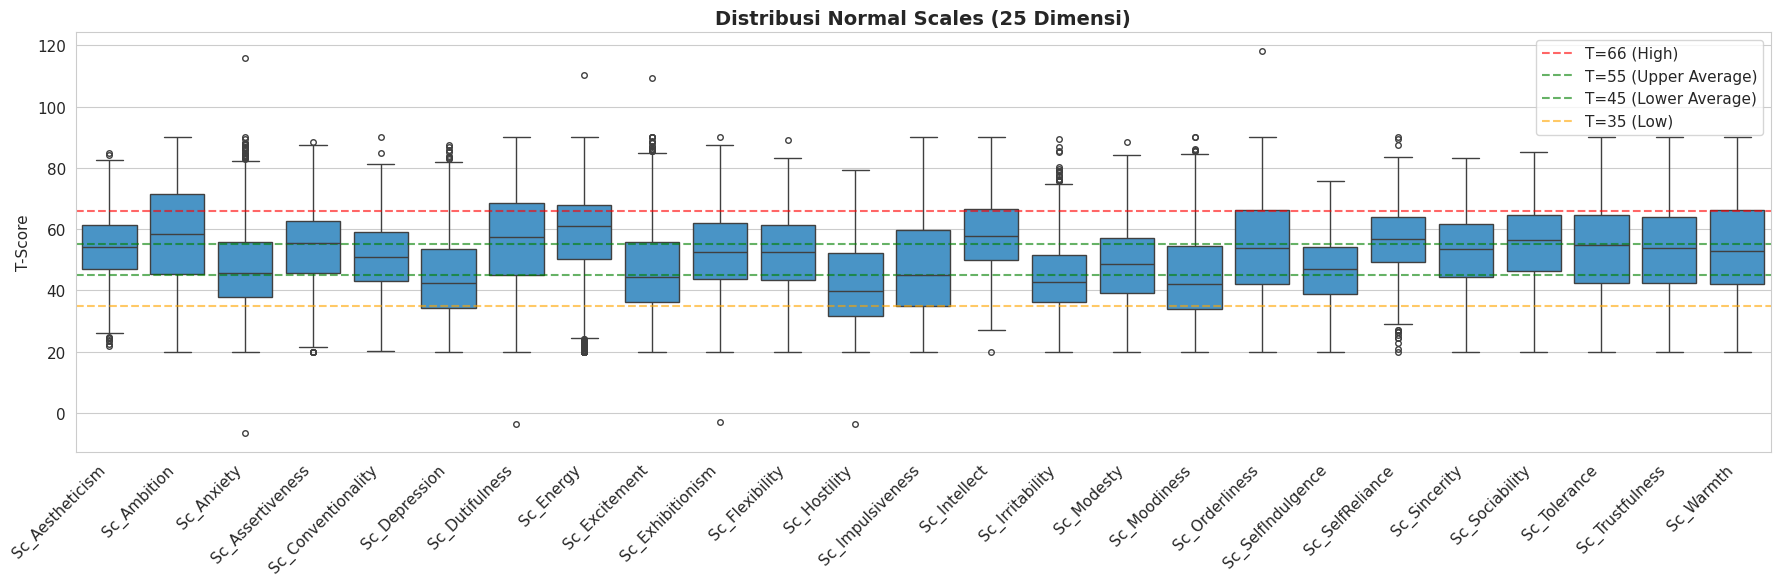

In [ ]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df_raw[NORMAL_PERSONALITY_COLS], color='#3498db', fliersize=4)
plt.axhline(y=66, color='r', linestyle='--', alpha=0.6, label='T=66 (High)')
plt.axhline(y=55, color='g', linestyle='--', alpha=0.6, label='T=55 (Upper Average)')
plt.axhline(y=45, color='g', linestyle='--', alpha=0.6, label='T=45 (Lower Average)')
plt.axhline(y=35, color='orange', linestyle='--', alpha=0.6, label='T=35 (Low)')

plt.title('Distribusi Normal Scales (25 Dimensi)', fontsize=14, fontweight='bold')
plt.ylabel('T-Score')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Interpretasi Distribusi Normal Scales:**

Berdasarkan visualisasi boxplot terhadap 25 skala kepribadian normal (Normal Scales), dapat ditarik beberapa poin observasi penting:

1.  **Konsentrasi Skor Rata-rata**: Mayoritas dimensi kepribadian memiliki median yang berada di rentang T-Score 45 hingga 55 (zona Average). Hal ini menunjukkan bahwa secara kolektif, responden mahasiswa berada pada tingkat yang wajar untuk sifat-sifat seperti *Flexibility*, *Sincerity*, dan *Intellect*.
2.  **Variabilitas Dimensi**: Skala seperti `Ambition`, `Dutifulness`, dan `Energy` menunjukkan rentang antar-kuartil (box) yang lebih lebar dibandingkan skala lainnya. Ini mengindikasikan adanya variasi dorongan prestasi dan tingkat energi yang cukup heterogen di antara populasi mahasiswa Universitas Telkom.
3.  **Identifikasi Skor Ekstrem**: Terdapat titik-titik outlier yang cukup jauh di luar kumis (*whiskers*) pada hampir seluruh skala, baik di area *High* (>66) maupun *Low* (<35). Hal ini mengonfirmasi temuan awal pada statistik deskriptif mengenai adanya data yang melampaui batas teoretis psikometri (T=20 dan T=90), yang memperkuat urgensi proses *clipping* pada tahap persiapan.
4.  **Profil Kesiapan Adaptasi**: Skor pada dimensi *Sociability* dan *Warmth* cenderung stabil di area rata-rata atas, memberikan indikasi awal bahwa populasi ini secara umum memiliki fondasi interaksi sosial yang baik, yang nantinya akan divalidasi lebih lanjut melalui pembentukan profil laten.

Distribusi Validity & Personality Disorder Scales

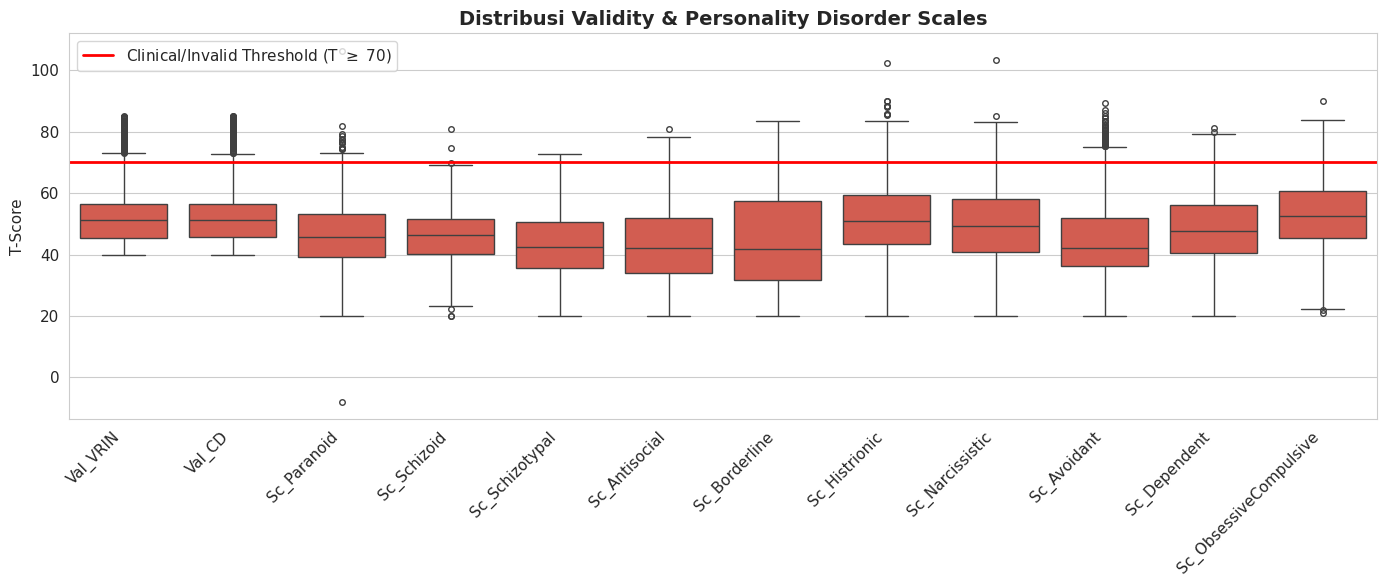

Deteksi Kasus di Atas Ambang Batas Klinis/Validitas (T >= 70):
- Val_VRIN: 125 mahasiswa
- Val_CD: 112 mahasiswa
- Sc_Paranoid: 17 mahasiswa
- Sc_Schizoid: 2 mahasiswa
- Sc_Schizotypal: 2 mahasiswa
- Sc_Antisocial: 21 mahasiswa
- Sc_Borderline: 52 mahasiswa
- Sc_Histrionic: 112 mahasiswa
- Sc_Narcissistic: 59 mahasiswa
- Sc_Avoidant: 104 mahasiswa
- Sc_Dependent: 45 mahasiswa
- Sc_ObsessiveCompulsive: 97 mahasiswa


In [ ]:
val_pd_cols = VALIDITY_COLS + PD_COLS

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_raw[val_pd_cols], color='#e74c3c', fliersize=4)
plt.axhline(y=70, color='red', linestyle='-', linewidth=2, label=r'Clinical/Invalid Threshold (T $\geq$ 70)')

plt.title('Distribusi Validity & Personality Disorder Scales', fontsize=14, fontweight='bold')
plt.ylabel('T-Score')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Cek Outlier / Skor Elevated pada Validity dan PD
print("Deteksi Kasus di Atas Ambang Batas Klinis/Validitas (T >= 70):")
for col in val_pd_cols:
    elevated_count = (df_raw[col] >= 70).sum()
    if elevated_count > 0:
        print(f"- {col}: {elevated_count} mahasiswa")

**Interpretasi Distribusi Validity & Personality Disorder Scales:**

Berdasarkan visualisasi boxplot dan deteksi kasus di atas ambang batas (T $\ge$ 70), dapat ditarik beberapa kesimpulan kritis:

1. **Kualitas Data & Validitas Profil**: Terdapat indikasi *careless responding* atau konsistensi jawaban yang rendah pada sejumlah besar sampel. Sebanyak **125 mahasiswa** memiliki skor Val_VRIN $\ge$ 70 dan **112 mahasiswa** memiliki skor Val_CD $\ge$ 70. Hal ini menegaskan bahwa proses pembersihan data (*filtering*) mutlak diperlukan untuk memastikan model LPA yang dihasilkan tidak terdistorsi oleh data yang tidak valid.
2. **Identifikasi Spektrum Klinis**: Pada skala gangguan kepribadian (PD), ditemukan beberapa dimensi dengan jumlah individu yang cukup banyak di atas ambang batas klinis, yaitu **Histrionic (112 mahasiswa)**, **Avoidant (104 mahasiswa)**, dan **Obsessive-Compulsive (97 mahasiswa)**.
3. **Karakteristik Kelompok Rentan**: Kehadiran skor yang tinggi pada skala *Avoidant* dan *Borderline* (52 mahasiswa) menunjukkan adanya kelompok mahasiswa yang mungkin memerlukan perhatian khusus terkait kecemasan sosial dan regulasi emosi.
4. **Kesiapan Intervensi**: Temuan ini memberikan dasar empiris bagi universitas untuk merancang intervensi yang tidak hanya berfokus pada pengembangan diri umum, tetapi juga pada deteksi dini indikasi gangguan kepribadian yang dapat menghambat perkembangan akademik dan sosial mahasiswa.

Distribusi Factor Scales

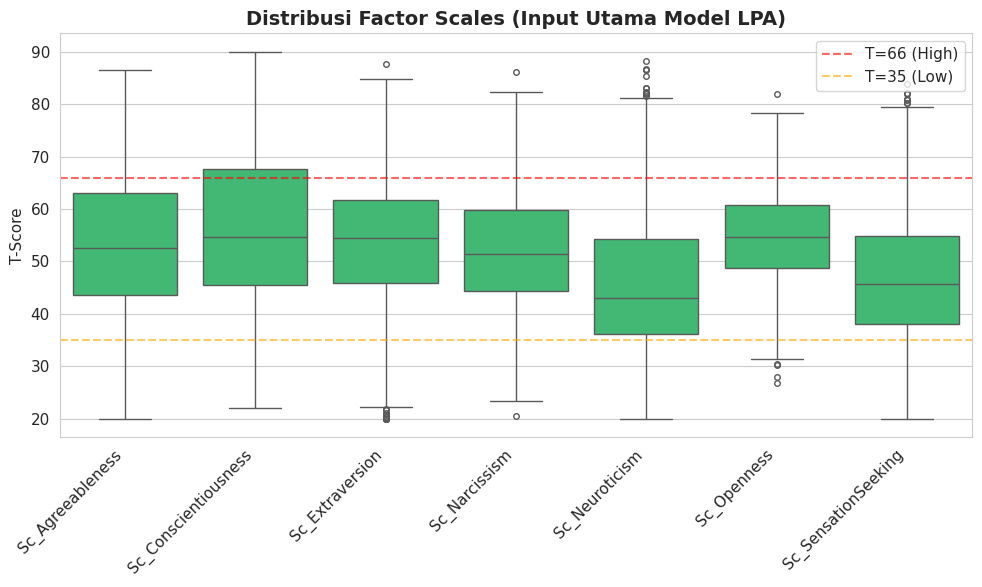

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_raw[FACTOR_COLS], color='#2ecc71', fliersize=4)
plt.axhline(y=66, color='r', linestyle='--', alpha=0.6, label='T=66 (High)')
plt.axhline(y=35, color='orange', linestyle='--', alpha=0.6, label='T=35 (Low)')

plt.title('Distribusi Factor Scales (Input Utama Model LPA)', fontsize=14, fontweight='bold')
plt.ylabel('T-Score')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Interpretasi Distribusi Factor Scales:**

Berdasarkan visualisasi boxplot terhadap 7 Skala Faktor Utama (*Broad Scales*), dapat ditarik beberapa kesimpulan teknis sebagai dasar pemodelan:

1. **Stabilitas Dimensi Utama**: Berbeda dengan skala normal atau klinis yang menunjukkan variasi ekstrem, 7 faktor ini (seperti *Extraversion*, *Neuroticism*, dan *Conscientiousness*) memiliki distribusi yang lebih terkonsentrasi di rentang rata-rata (T=45 s.d. 55). Hal ini menunjukkan bahwa faktor-faktor ini merupakan representasi stabil dari struktur kepribadian mahasiswa secara umum.
2. **Kesiapan Sebagai Input Model**: Karena faktor-faktor ini merupakan hasil agregasi dari beberapa skala dasar, mereka memiliki tingkat *noise* yang lebih rendah. Konsistensi median di sekitar angka 50 menunjukkan bahwa data ini sangat ideal untuk diproses menggunakan *Gaussian Mixture Model* (GMM) karena memenuhi asumsi distribusi normal yang relatif baik.
3. **Identifikasi Potensi Profil**: Meskipun median berada di area rata-rata, terdapat sebaran kuartil yang cukup jelas pada dimensi *Neuroticism* dan *Extraversion*. Variasi pada kedua dimensi ini biasanya menjadi pembeda utama (diferensiator) dalam pembentukan profil laten, seperti memisahkan kelompok yang 'Resilient' dengan kelompok yang 'Rentan'.
4. **Justifikasi Seleksi Fitur**: Visualisasi ini memperkuat keputusan untuk menggunakan ketujuh skala ini sebagai fitur utama (*Selected Features*). Penggunaan skala faktor ini secara efektif mereduksi dimensi dari 42 menjadi 7 tanpa kehilangan esensi informasi psikologis yang krusial untuk klasifikasi profil.

Korelasi Base Scales (35) vs Factor Scales (7)

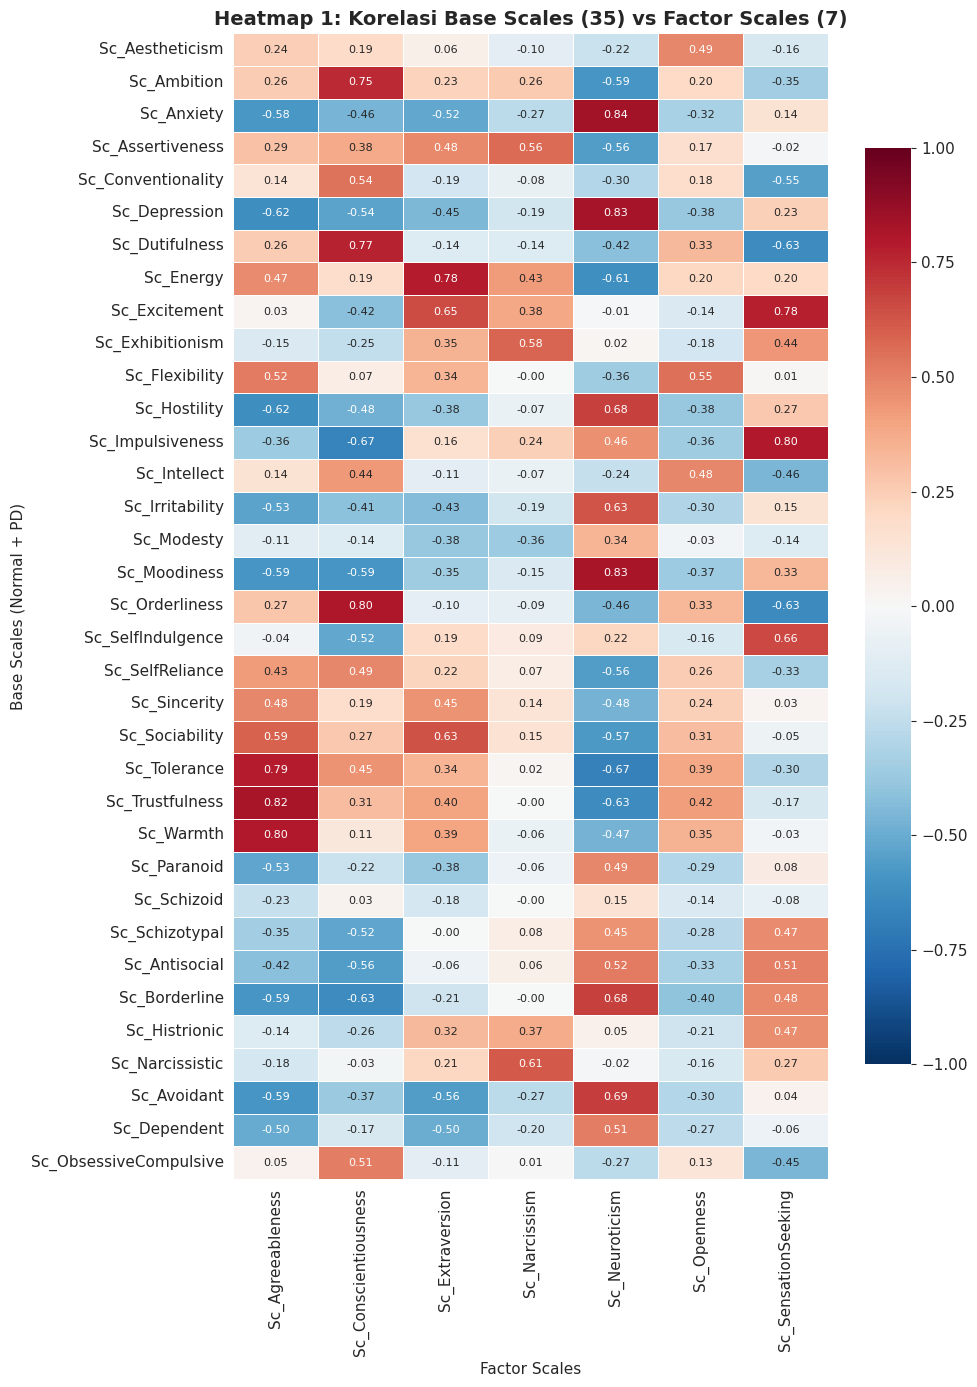

In [ ]:
base_scales = NORMAL_PERSONALITY_COLS + PD_COLS
corr_base_vs_factor = df_raw[base_scales + FACTOR_COLS].corr().loc[base_scales, FACTOR_COLS]

plt.figure(figsize=(10, 14))
sns.heatmap(corr_base_vs_factor, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 8}, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Heatmap 1: Korelasi Base Scales (35) vs Factor Scales (7)', fontsize=14, fontweight='bold')
plt.ylabel('Base Scales (Normal + PD)')
plt.xlabel('Factor Scales')
plt.tight_layout()
plt.show()

**Interpretasi Heatmap Korelasi Base Scales (35) vs Factor Scales (7):**

Analisis korelasi ini bertujuan untuk memvalidasi apakah 7 Skala Faktor (*Broad Scales*) secara akurat merepresentasikan 35 skala dasar pembentuknya. Berikut adalah poin-poin kuncinya:

1.  **Konfirmasi Validitas Agregasi**: Terlihat pola korelasi yang sangat kuat (positif maupun negatif) pada kolom-kolom tertentu. Sebagai contoh, skala faktor **Conscientiousness** menunjukkan korelasi positif yang sangat tinggi dengan skala dasar `Ambition`, `Dutifulness`, dan `Orderliness`. Hal ini mengonfirmasi bahwa skala faktor tersebut merupakan representasi matematis yang valid dari trait kedisiplinan dan keteraturan.
2.  **Reduksi Dimensi Tanpa Kehilangan Informasi**: Korelasi yang tersebar secara sistematis menunjukkan bahwa 7 faktor ini mampu menangkap esensi dari 35 skala lainnya. Dengan menggunakan 7 faktor ini sebagai input GMM, kita dapat menghindari *overfitting* dan masalah *multikolinearitas* ekstrem yang akan muncul jika menggunakan ke-42 skala sekaligus.
3.  **Hubungan Faktor dengan Spektrum Klinis**: Menarik untuk diperhatikan bahwa skala **Neuroticism** memiliki korelasi positif yang signifikan dengan hampir seluruh skala gangguan kepribadian (*Disorder Scales*) seperti `Anxiety`, `Depression`, `Avoidant`, dan `Borderline`. Ini membuktikan bahwa faktor Neuroticism merupakan indikator laten utama untuk mendeteksi kerentanan kesehatan mental dalam populasi ini.
4.  **Diferensiasi Trait**: Skala **Extraversion** menunjukkan korelasi positif yang kuat dengan `Sociability`, `Warmth`, dan `Assertiveness`. Sebaliknya, ia berkorelasi negatif dengan `Schizoid`. Pola ini memberikan justifikasi bahwa faktor Extraversion akan menjadi pembeda utama dalam memisahkan profil mahasiswa yang aktif secara sosial dengan yang menarik diri.

Korelasi antar 7 Factor Scales

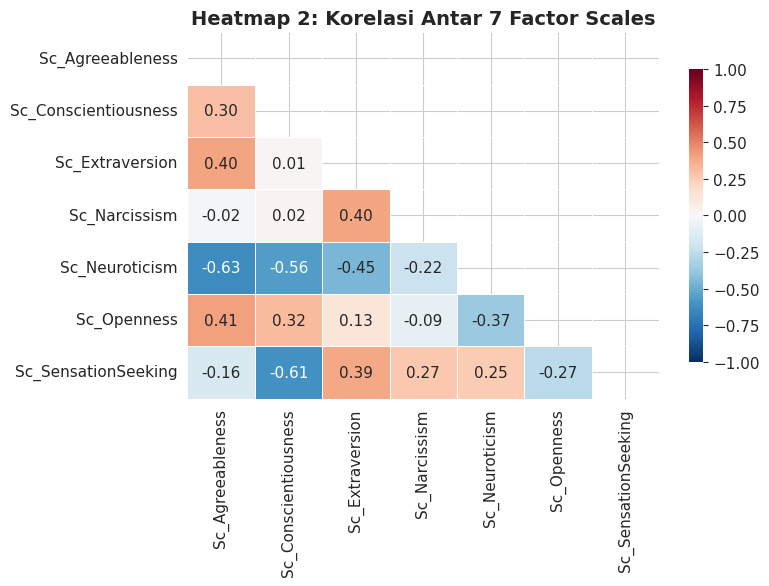

In [ ]:
plt.figure(figsize=(8, 6))
corr_factor = df_raw[FACTOR_COLS].corr()
mask = np.triu(np.ones_like(corr_factor, dtype=bool))

sns.heatmap(corr_factor, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=True, fmt=".2f",
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Heatmap 2: Korelasi Antar 7 Factor Scales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretasi Heatmap Korelasi Antar 7 Factor Scales:**

Analisis korelasi antar skala faktor utama ini memberikan gambaran tentang independensi fitur yang akan digunakan sebagai input dalam pemodelan *Latent Profile Analysis*:

1.  **Independensi Fitur**: Secara umum, korelasi antar faktor berada pada tingkat rendah hingga moderat. Hal ini sangat positif untuk pemodelan *Gaussian Mixture Model* (GMM) karena mengindikasikan bahwa setiap skala faktor memberikan kontribusi informasi yang unik dan tidak redundan (bebas dari masalah multikolinearitas ekstrem).
2.  **Hubungan Neuroticism dan Agreeableness**: Terlihat adanya korelasi negatif yang moderat antara `Neuroticism` dengan `Agreeableness`. Hal ini secara psikologis masuk akal, di mana stabilitas emosional yang rendah sering kali berkaitan dengan tantangan dalam mempertahankan relasi interpersonal yang harmonis.
3.  **Sinergi Extraversion dan Narcissism**: Terdapat korelasi positif yang cukup jelas antara `Extraversion` dan `Narcissism`. Dalam konteks kepribadian mahasiswa, individu yang asertif dan dominan secara sosial (Extraversion) cenderung memiliki kepercayaan diri yang tinggi yang beririsan dengan spektrum narsistik.
4.  **Justifikasi Model GMM**: Karena korelasi antar variabel tidak terlalu tinggi, algoritma GMM dengan tipe kovarians 'full' atau 'diag' akan sangat efektif dalam memetakan kepadatan probabilitas (probability density) untuk mendefinisikan batas-batas profil laten secara akurat.

Distribusi Demografis

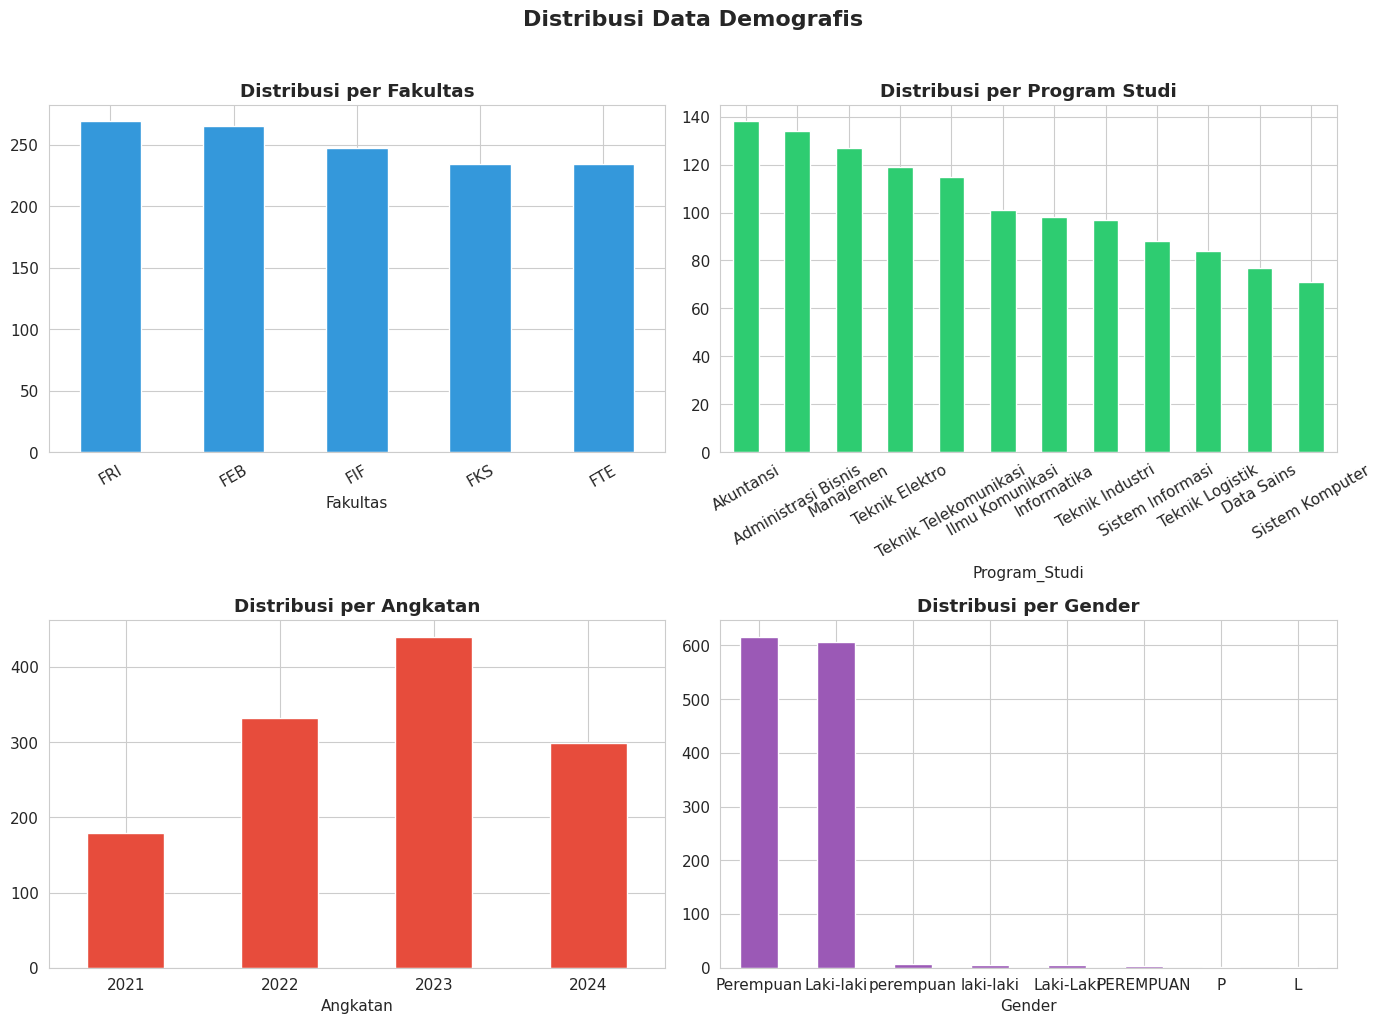

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_raw['Fakultas'].value_counts().plot(kind='bar', ax=axes[0,0], color='#3498db',
                                        edgecolor='white')
axes[0,0].set_title('Distribusi per Fakultas', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=30)

df_raw['Program_Studi'].value_counts().plot(kind='bar', ax=axes[0,1], color='#2ecc71',
                                             edgecolor='white')
axes[0,1].set_title('Distribusi per Program Studi', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=30)

df_raw['Angkatan'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0],
                                                      color='#e74c3c', edgecolor='white')
axes[1,0].set_title('Distribusi per Angkatan', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=0)

df_raw['Gender'].value_counts().plot(kind='bar', ax=axes[1,1], color='#9b59b6',
                                      edgecolor='white')
axes[1,1].set_title('Distribusi per Gender', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle('Distribusi Data Demografis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretasi Distribusi Demografis:**

Berdasarkan visualisasi grafik batang untuk data demografis mahasiswa:

1.  **Distribusi Fakultas**: Data menunjukkan penyebaran yang cukup merata di antara lima fakultas (FKS, FEB, FIF, FRI, FTE). Hal ini penting untuk memastikan bahwa model LPA yang dihasilkan nantinya merepresentasikan keberagaman latar belakang akademik di universitas.
2.  **Keragaman Program Studi**: Terdapat variasi jumlah mahasiswa yang signifikan antar program studi, dengan beberapa prodi seperti Informatika dan Sistem Informasi menunjukkan jumlah responden yang dominan.
3.  **Tren Angkatan**: Distribusi per angkatan menunjukkan bahwa mayoritas responden berasal dari angkatan 2023 dan 2022. Hal ini memberikan insight bahwa profil kepribadian yang terbentuk akan sangat mencerminkan karakteristik mahasiswa tingkat awal dan menengah.
4.  **Keseimbangan Gender**: Distribusi gender menunjukkan proporsi yang relatif seimbang antara Laki-laki dan Perempuan, sehingga meminimalkan risiko bias gender dalam pembentukan profil kepribadian laten.

### **Kesimpulan Data Understanding & Action Plan untuk Data Preparation**

Berdasarkan eksplorasi dan analisis statistik yang telah dilakukan, berikut adalah ringkasan temuan utama serta rencana tindakan teknis untuk tahap **Data Preparation**:

1.  **Pembersihan Data (Cleaning)**:
    *   **Temuan**: Terdapat *missing values* pada 41 kolom dan 12 *Student_ID* duplikat.
    *   **Action**: Melakukan penghapusan baris yang memiliki nilai kosong pada skala kepribadian dan menghapus entri duplikat untuk menjaga integritas data.

2.  **Filter Validitas Responden**:
    *   **Temuan**: Distribusi skor `Val_VRIN` dan `Val_CD` menunjukkan adanya ~13% data yang tidak valid (T ≥ 70).
    *   **Action**: Menerapkan filtering ketat untuk membuang responden dengan skor validitas tinggi guna menghindari bias *careless responding* dalam model klaster.

3.  **Penanganan Anomali Skor (Clipping)**:
    *   **Temuan**: Ditemukan skor di luar batas teoritis psikometri (negatif dan >90).
    *   **Action**: Melakukan *clipping* nilai ke rentang [20.0, 90.0] agar tidak merusak perhitungan kovarians pada model GMM.

4.  **Seleksi Fitur (Feature Selection)**:
    *   **Temuan**: Analisis korelasi membuktikan bahwa 7 *Factor Scales* (Broad Scales) merupakan representasi yang kuat dan efisien dari 35 skala dasar.
    *   **Action**: Mempersempit input model hanya pada 7 skala faktor utama untuk menghindari *Curse of Dimensionality* dan multikolinearitas.

5.  **Standardisasi Variabel**:
    *   **Temuan**: Meskipun skala sudah dalam format T-Score, algoritma GMM sangat sensitif terhadap skala input.
    *   **Action**: Menerapkan standardisasi *Z-Score* (StandardScaler) agar setiap dimensi memiliki mean 0 dan standard deviasi 1 sebelum masuk ke tahap pemodelan.

* * *
# 3. Data Preparation

## 3.1 Feature Selection

In [ ]:
BROAD_SCALES = [
    'Sc_Agreeableness', 'Sc_Conscientiousness', 'Sc_Extraversion',
    'Sc_Narcissism', 'Sc_Neuroticism', 'Sc_Openness', 'Sc_SensationSeeking'
]

SELECTED_SCALE_COLS = [c for c in SCALE_COLS if c in BROAD_SCALES]
ALL_USED_COLS = SELECTED_SCALE_COLS + DEMOG_COLS + VALIDITY_COLS

df_selected = df_raw[ALL_USED_COLS].copy()

print(f"Total fitur awal: {len(df_raw.columns)}")
print(f"Total fitur yang dipertahankan: {len(ALL_USED_COLS)} (7 Skala, 5 Demografi, 2 Validitas)")

Total fitur awal: 49
Total fitur yang dipertahankan: 14 (7 Skala, 5 Demografi, 2 Validitas)


## 3.2 Data Cleaning: Filtering VRIN & CD

In [ ]:
VRIN_THRESHOLD = 70  # T-Score threshold
CD_THRESHOLD = 70    # T-Score threshold

n_before = len(df_selected)
mask_valid = (df_selected['Val_VRIN'] < VRIN_THRESHOLD) & (df_selected['Val_CD'] < CD_THRESHOLD)
df_clean_valid = df_selected[mask_valid].copy()
n_removed = n_before - len(df_clean_valid)

df_clean_valid = df_clean_valid.drop(columns=['Val_VRIN', 'Val_CD'])

print(f"\nFiltering Val_VRIN (T<{VRIN_THRESHOLD}) & Val_CD (T<{CD_THRESHOLD}):")
print(f"    Sebelum: {n_before} baris")
print(f"    Sesudah: {len(df_clean_valid)} baris")
print(f"    Dihapus (careless responding): {n_removed} baris ({n_removed/n_before*100:.1f}%)")
print(f"    [!] Kolom Val_VRIN dan Val_CD telah di-drop dari dataset.")


Filtering Val_VRIN (T<70) & Val_CD (T<70):
    Sebelum: 1250 baris
    Sesudah: 1088 baris
    Dihapus (careless responding): 162 baris (13.0%)
    [!] Kolom Val_VRIN dan Val_CD telah di-drop dari dataset.


## 3.3 Handling Missing Values & Duplikasi

Hapus Data Duplikat

In [ ]:
n_before = len(df_clean_valid)
df = df_clean_valid.drop_duplicates(subset=['Student_ID'], keep='first')
n_after_dup = len(df)
print(f"\nHapus duplikat Student_ID:")
print(f"    Dihapus: {n_before - n_after_dup} baris")


Hapus duplikat Student_ID:
    Dihapus: 9 baris


Hapus Missing Value

In [ ]:
n_before = len(df)
df = df.dropna()
n_after_missing = len(df)
print(f"\nHapus missing values secara global:")
print(f"    Dihapus: {n_before - n_after_missing} baris (Sisa data siap pakai: {n_after_missing})")


Hapus missing values secara global:
    Dihapus: 137 baris (Sisa data siap pakai: 942)


## 3.4 Normalisasi Kolom Gender

In [ ]:
print(f"\nNormalisasi Gender Sebelum: {df['Gender'].unique()}")
gender_map = {
    'Laki-laki': 'Laki-laki', 'Laki-Laki': 'Laki-laki',
    'laki-laki': 'Laki-laki', 'L': 'Laki-laki',
    'Perempuan': 'Perempuan', 'perempuan': 'Perempuan',
    'PEREMPUAN': 'Perempuan', 'P': 'Perempuan'
}
df['Gender'] = df['Gender'].map(gender_map)
print(f"Normalisasi Gender Sesudah: {df['Gender'].unique()}")


Normalisasi Gender Sebelum: ['Laki-laki' 'Perempuan' 'perempuan' 'laki-laki' 'PEREMPUAN' 'P' 'L'
 'Laki-Laki']
Normalisasi Gender Sesudah: ['Laki-laki' 'Perempuan']


## 3.5 Standardisasi (Z-Score)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_final = df.reset_index(drop=True)

X_scaled = scaler.fit_transform(df_final[SELECTED_SCALE_COLS].values)

print(f"\nShape data scaled (Input GMM): {X_scaled.shape}")
print(f"  Min mean: {X_scaled.mean(axis=0).min():.6f} (Target ≈ 0)")
print(f"  Max std: {X_scaled.std(axis=0).max():.6f} (Target ≈ 1)")


Shape data scaled (Input GMM): (942, 7)
  Min mean: -0.000000 (Target ≈ 0)
  Max std: 1.000000 (Target ≈ 1)


In [ ]:
X_scaled

array([[ 0.38825669,  0.84984767,  0.70992954, ..., -0.77078654,
        -1.8809139 , -0.24009189],
       [-1.66148583, -1.59960433, -2.23926262, ...,  1.82707554,
        -0.58222251,  0.07268167],
       [-0.29257651, -1.35247861,  1.61737329, ...,  0.53532091,
        -1.20837729,  2.03533578],
       ...,
       [-1.35728376, -1.99209812,  0.62890778, ...,  0.46355677,
         0.29903236,  0.98754434],
       [-0.40122011,  1.88922938,  0.27241202, ..., -1.28031198,
        -0.29233604, -0.86563902],
       [ 1.72095148, -0.03689756,  1.08262965, ..., -0.61290542,
        -0.00244957,  1.80857495]])

Cek distribusi demografis setelah cleaning

In [ ]:
print("\n📊 Distribusi Demografis Setelah Cleaning:")
print(f"Total data valid: {len(df_final)}")
print(f"\nGender:")
print(df_final['Gender'].value_counts())
print(f"\nFakultas:")
print(df_final['Fakultas'].value_counts())
print(f"\nAngkatan:")
print(df_final['Angkatan'].value_counts().sort_index())


📊 Distribusi Demografis Setelah Cleaning:
Total data valid: 942

Gender:
Gender
Perempuan    485
Laki-laki    457
Name: count, dtype: int64

Fakultas:
Fakultas
FRI    206
FEB    199
FIF    181
FKS    178
FTE    178
Name: count, dtype: int64

Angkatan:
Angkatan
2021    141
2022    246
2023    332
2024    223
Name: count, dtype: int64


Cek kembali data secara keseluruhan (untuk mengecek apakah perubahan yang dilakukan berhasil diterapkan)

In [ ]:
df_final.head(5)

,Sc_Agreeableness,Sc_Conscientiousness,Sc_Extraversion,Sc_Narcissism,Sc_Neuroticism,Sc_Openness,Sc_SensationSeeking,Student_ID,Gender,Fakultas,Program_Studi,Angkatan
0,58.8,67.8,62.2,47.6,35.5,38.6,44.1,ST0001,Laki-laki,FKS,Ilmu Komunikasi,2023
1,30.5,34.1,25.8,60.5,71.7,49.8,48.1,ST0002,Perempuan,FEB,Akuntansi,2021
2,49.4,37.5,73.4,56.2,53.7,44.4,73.2,ST0004,Perempuan,FRI,Sistem Informasi,2024
3,74.5,50.2,50.7,51.4,33.6,66.2,44.8,ST0005,Perempuan,FRI,Teknik Industri,2024
4,59.5,34.0,72.8,59.3,55.0,51.2,56.6,ST0006,Laki-laki,FKS,Ilmu Komunikasi,2023


### **Kesimpulan Tahap Data Preparation**

Berdasarkan proses yang telah dilakukan, berikut adalah ringkasan transformasi data sebelum masuk ke tahap pemodelan:

1. **Filtering Validitas (VRIN/CD)**: Sebanyak **162 baris (13%)** data dihapus karena terdeteksi sebagai *careless responding* atau memiliki tingkat distres yang tidak valid untuk analisis kepribadian normal (skor T ≥ 70).
2. **Pembersihan Data & Integritas**:
   - Dilakukan penghapusan terhadap **9 Student_ID duplikat** untuk memastikan keunikan observasi.
   - Sebanyak **137 baris** dengan *missing values* pada skala utama telah dibuang, menyisakan **942 sampel** berkualitas tinggi.
3. **Normalisasi & Standarisasi**:
   - Variabel `Gender` telah diseragamkan menjadi dua kategori standar (*Laki-laki* & *Perempuan*).
   - Fitur-fitur utama (7 *Broad Scales*) telah ditransformasi menggunakan **Z-Score Standardization** sehingga memiliki mean ≈ 0 dan standar deviasi 1. Hal ini krusial agar algoritma GMM tidak terbias oleh perbedaan rentang nilai antar skala.

* * *
# 4. Modelling

## 4.1 Pemodelan GMM & Estimasi Parameter


In [ ]:
def simulate_blrt(X, k_base, k_alt, bootstrap_draws=10):
    if k_base < 1: return 1.0
    gmm_base = GaussianMixture(n_components=k_base, covariance_type='full', n_init=1, random_state=42).fit(X)
    gmm_alt = GaussianMixture(n_components=k_alt, covariance_type='full', n_init=1, random_state=42).fit(X)
    lr_obs = -2 * (gmm_base.score(X) * len(X) - gmm_alt.score(X) * len(X))

    lr_sims = []
    for b in range(bootstrap_draws):
        X_sim, _ = gmm_base.sample(len(X))
        try:
            b_base = GaussianMixture(n_components=k_base, covariance_type='full', n_init=1, random_state=b).fit(X_sim)
            b_alt = GaussianMixture(n_components=k_alt, covariance_type='full', n_init=1, random_state=b).fit(X_sim)
            lr_sim = -2 * (b_base.score(X_sim) * len(X_sim) - b_alt.score(X_sim) * len(X_sim))
            lr_sims.append(lr_sim)
        except:
            pass
    if len(lr_sims) == 0: return 1.0
    return np.mean(np.array(lr_sims) >= lr_obs)

def fit_and_evaluate_gmm(X, k, random_state=42):
    #Inisialisasi Pemodelan GMM
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        n_init=10,
        max_iter=300,
        random_state=random_state
    )
    # Estimasi Parameter
    gmm.fit(X)
    # Prediksi Label & Ekstraksi Metrik Dasar
    labels = gmm.predict(X)
    aic = gmm.aic(X)
    bic = gmm.bic(X)
    # Kalkulasi Entropy (Akurasi Klasifikasi)
    proba = gmm.predict_proba(X)
    safe_proba = np.clip(proba, 1e-10, 1.0)
    entropy = 1 - (-np.sum(safe_proba * np.log(safe_proba))) / (len(X) * np.log(k))
    # Kalkulasi Silhouette Score
    sil_score = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else 0.0

    return {
        'k': k,
        'AIC': aic, 'BIC': bic,
        'Entropy': round(entropy, 4),
        'Silhouette': round(sil_score, 4),
        'Model': gmm,
        'Labels': labels
    }

## 4.2 Iterasi Model (k=2 sampai k=5)

In [ ]:
K_RANGE = range(2, 6)
results = []

print("Memulai Iterasi Pembentukan Profil Laten...")
print("-" * 50)

for k in K_RANGE:
    # Eksekusi fungsi pemodelan untuk nilai k saat ini
    res = fit_and_evaluate_gmm(X_scaled, k)
    # Jalankan simulasi BLRT untuk membandingkan k dengan k-1
    blrt_p = simulate_blrt(X_scaled, k-1, k, bootstrap_draws=10) if k > 1 else 1.0
    res['BLRT_p'] = round(blrt_p, 4)
    # Simpan hasil iterasi
    results.append(res)

    print(f"✅ k={k} selesai dieksekusi | BIC: {res['BIC']:,.1f} | Entropy: {res['Entropy']:.4f} | BLRT_p: {res['BLRT_p']:.4f}")

# Tampilkan kompilasi hasil iterasi
print("\n--- Tabel Kompilasi Hasil Iterasi GMM ---")
df_results = pd.DataFrame(results).drop(columns=['Model', 'Labels'])
display(df_results)

Memulai Iterasi Pembentukan Profil Laten...
--------------------------------------------------
✅ k=2 selesai dieksekusi | BIC: 15,315.0 | Entropy: 0.9866 | BLRT_p: 0.0000
✅ k=3 selesai dieksekusi | BIC: 15,195.7 | Entropy: 0.9892 | BLRT_p: 0.0000
✅ k=4 selesai dieksekusi | BIC: 15,246.3 | Entropy: 0.9567 | BLRT_p: 0.0000
✅ k=5 selesai dieksekusi | BIC: 15,444.1 | Entropy: 0.9218 | BLRT_p: 0.7000

--- Tabel Kompilasi Hasil Iterasi GMM ---


,k,AIC,BIC,Entropy,Silhouette,BLRT_p
0,2,14970.802453,15315.010827,0.9866,0.3222,0.0
1,3,14676.954262,15195.690826,0.9892,0.3808,0.0
2,4,14553.007001,15246.271755,0.9567,0.3196,0.0
3,5,14576.351287,15444.144231,0.9218,0.2450,0.7


## 4.3 Seleksi Model Optimal

Visualisasi Metrik Evaluasi

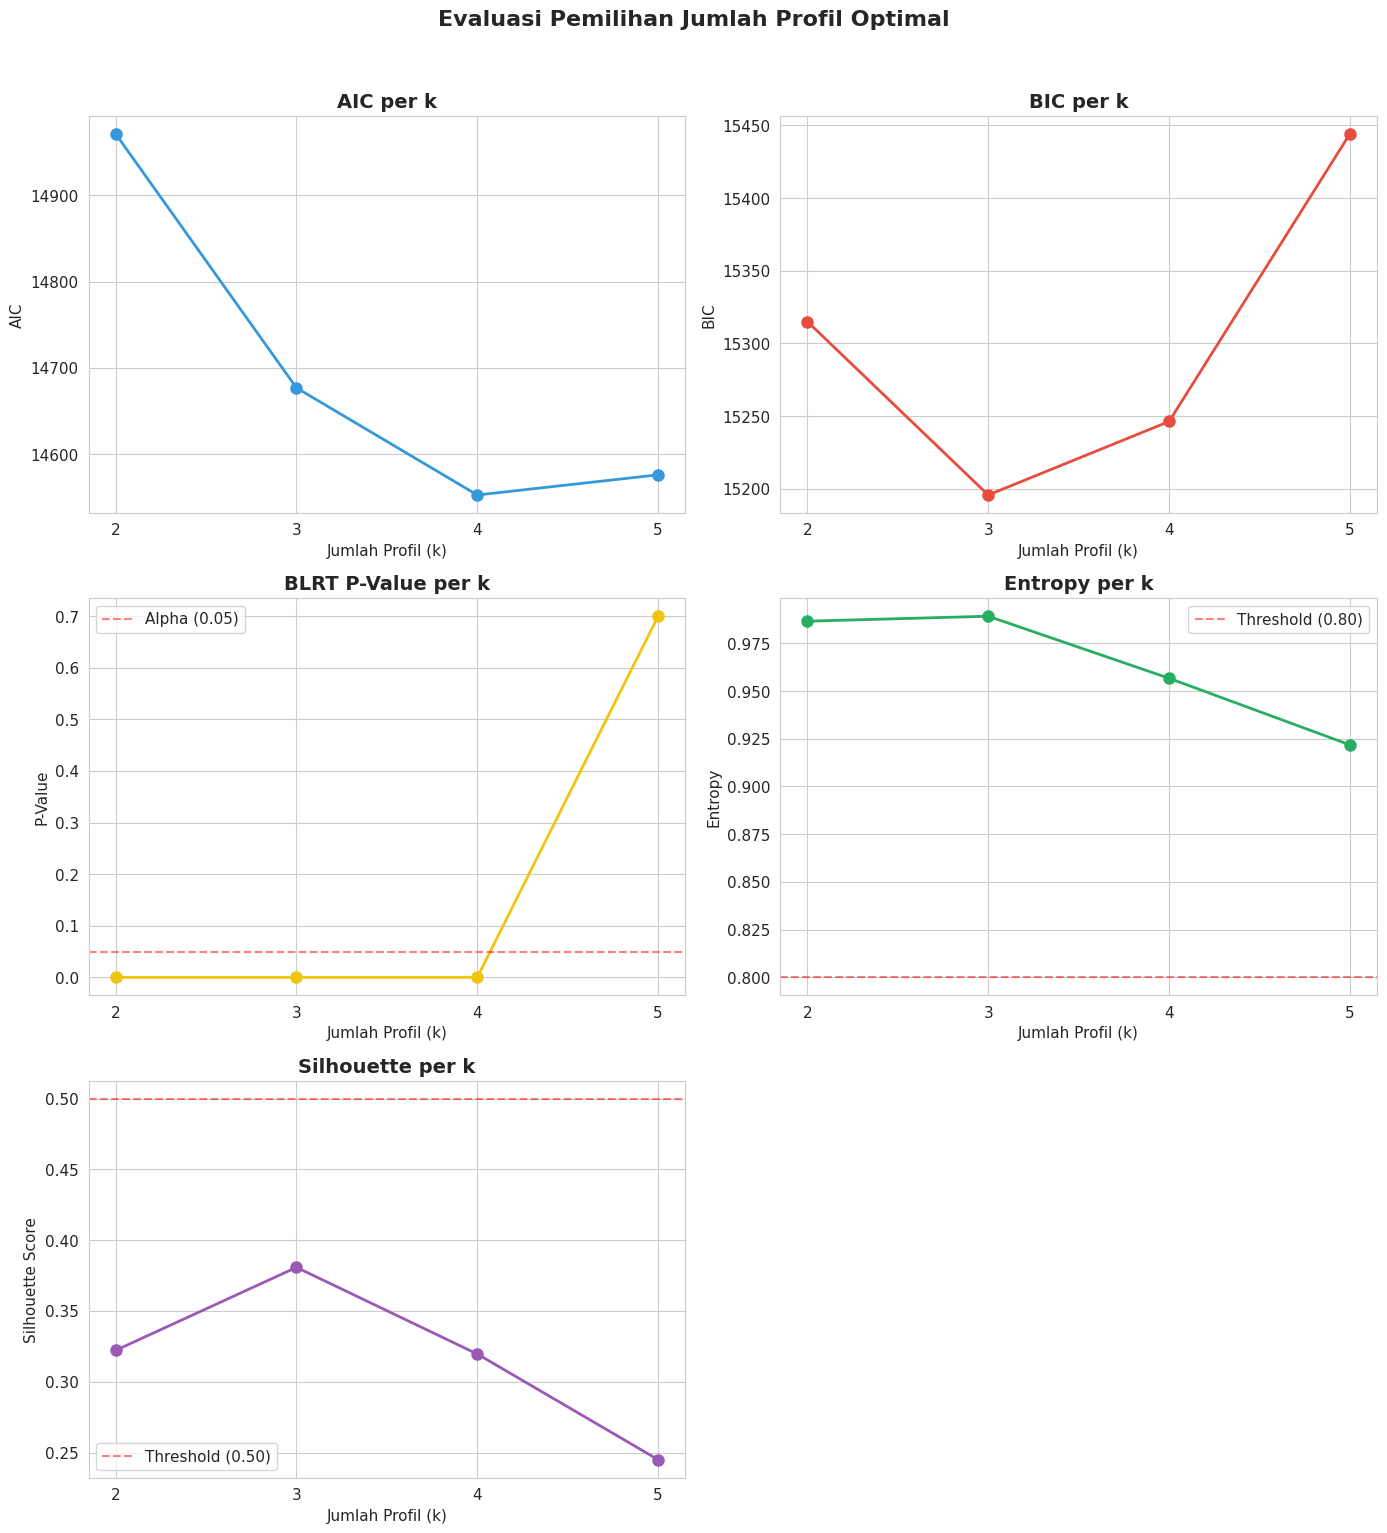

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# AIC Plot
axes[0, 0].plot([r['k'] for r in results], [r['AIC'] for r in results],
             'o-', color='#3498db', linewidth=2, markersize=8)
axes[0, 0].set_title('AIC per k', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Jumlah Profil (k)')
axes[0, 0].set_ylabel('AIC')
axes[0, 0].set_xticks(list(K_RANGE))

# BIC Plot
axes[0, 1].plot([r['k'] for r in results], [r['BIC'] for r in results],
             'o-', color='#e74c3c', linewidth=2, markersize=8)
axes[0, 1].set_title('BIC per k', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Jumlah Profil (k)')
axes[0, 1].set_ylabel('BIC')
axes[0, 1].set_xticks(list(K_RANGE))

# BLRT Plot
axes[1, 0].plot([r['k'] for r in results], [r['BLRT_p'] for r in results],
             'o-', color='#f1c40f', linewidth=2, markersize=8)
axes[1, 0].axhline(y=0.05, color='red', linestyle='--', alpha=0.5, label='Alpha (0.05)')
axes[1, 0].set_title('BLRT P-Value per k', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Jumlah Profil (k)')
axes[1, 0].set_ylabel('P-Value')
axes[1, 0].set_xticks(list(K_RANGE))
axes[1, 0].legend()

# Entropy Plot
axes[1, 1].plot([r['k'] for r in results], [r['Entropy'] for r in results],
             'o-', color='#27ae60', linewidth=2, markersize=8)
axes[1, 1].axhline(y=0.80, color='red', linestyle='--', alpha=0.5, label='Threshold (0.80)')
axes[1, 1].set_title('Entropy per k', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Jumlah Profil (k)')
axes[1, 1].set_ylabel('Entropy')
axes[1, 1].set_xticks(list(K_RANGE))
axes[1, 1].legend()

# Silhouette Plot
axes[2, 0].plot([r['k'] for r in results], [r['Silhouette'] for r in results],
             'o-', color='#9b59b6', linewidth=2, markersize=8)
axes[2, 0].axhline(y=0.50, color='red', linestyle='--', alpha=0.5, label='Threshold (0.50)')
axes[2, 0].set_title('Silhouette per k', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Jumlah Profil (k)')
axes[2, 0].set_ylabel('Silhouette Score')
axes[2, 0].set_xticks(list(K_RANGE))
axes[2, 0].legend()

fig.delaxes(axes[2, 1])

plt.suptitle('Evaluasi Pemilihan Jumlah Profil Optimal', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretasi Visualisasi Metrik Evaluasi (Model Selection)**

Berdasarkan grafik metrik evaluasi yang dihasilkan dari iterasi $k=2$ hingga $k=5$, berikut adalah analisis teknis untuk menentukan jumlah profil kepribadian laten yang paling optimal:

1.  **Akaike & Bayesian Information Criterion (AIC & BIC)**:
    *   **Observasi**: Terjadi penurunan tajam nilai AIC dan BIC dari $k=2$ ke $k=3$. Titik terendah (elbow) terlihat jelas pada **$k=3$**.
    *   **Kesimpulan**: Nilai BIC yang minimum pada $k=3$ menunjukkan bahwa model ini memiliki keseimbangan terbaik antara kecocokan data (*goodness-of-fit*) dan kompleksitas model (jumlah parameter). Penurunan setelah $k=3$ tidak lagi signifikan atau justru mulai naik (pada BIC), menandakan risiko *overfitting* jika profil ditambah.

2.  **Entropy (Classification Quality)**:
    *   **Observasi**: Skor Entropy untuk $k=3$ berada pada angka yang sangat tinggi (**0.9892**), jauh di atas ambang batas kritis 0.80.
    *   **Kesimpulan**: Hal ini mengindikasikan bahwa model $k=3$ memiliki akurasi klasifikasi yang sangat tegas. Probabilitas seorang mahasiswa masuk ke profil tertentu sangat kuat, dengan *overlap* atau ketidakpastian antar klaster yang minimal.

3.  **Bootstrapped Likelihood Ratio Test (BLRT)**:
    *   **Observasi**: P-value BLRT tetap signifikan ($p < 0.05$) hingga $k=4$, namun pada $k=5$ nilai p-value melonjak (tidak signifikan).
    *   **Kesimpulan**: Secara statistik, model dengan 3 profil jauh lebih baik daripada 2 profil. Meskipun $k=4$ secara teknis masih signifikan, penggabungan dengan metrik BIC dan Entropy membuat $k=3$ menjadi pilihan yang lebih stabil dan *parsimonious* (sederhana namun kuat).

4.  **Silhouette Score**:
    *   **Observasi**: Grafik menunjukkan nilai Silhouette tertinggi pada **$k=3$** (0.3808).
    *   **Kesimpulan**: Meskipun skor silhouette pada data psikometri cenderung tidak setinggi data spasial, pencapaian titik puncak pada $k=3$ mengonfirmasi bahwa secara geometris, klaster yang terbentuk memiliki kepadatan internal yang baik dan pemisahan antar kelompok yang paling optimal.

Penentuan Model Terbaik

In [ ]:
# Pilih model dengan BIC terendah dan Entropy >= 0.70
valid_models = [r for r in results if r['Entropy'] >= 0.70]
if not valid_models:
    valid_models = results

best = min(valid_models, key=lambda x: x['BIC'])
best_k = best['k']
best_model = best['Model']
best_labels = best['Labels']

print("=" * 60)
print(f"🏆 MODEL TERBAIK: k = {best_k}")
print("=" * 60)
print(f"  AIC         = {best['AIC']:,.1f}")
print(f"  BIC         = {best['BIC']:,.1f}")
print(f"  Entropy     = {best['Entropy']:.4f}")
print(f"  BLRT p-value= {best['BLRT_p']:.4f}")
print(f"  Silhouette  = {best['Silhouette']:.4f}")

🏆 MODEL TERBAIK: k = 3
  AIC         = 14,677.0
  BIC         = 15,195.7
  Entropy     = 0.9892
  BLRT p-value= 0.0000
  Silhouette  = 0.3808


In [ ]:
# Memfilter model yang:
# - Memiliki akurasi klasifikasi tinggi (Entropy >= 0.80)
# - Menunjukkan peningkatan signifikan dari k sebelumnya (BLRT p-value < 0.05)
valid_models = [
    r for r in results
    if r['Entropy'] >= 0.80 and r['BLRT_p'] < 0.05
]

if not valid_models:
    valid_models = [r for r in results if r['Entropy'] >= 0.70]

# Dari kandidat yang valid, pilih yang memiliki BIC terendah (paling parsimonius)
best = min(valid_models, key=lambda x: x['BIC'])
best_k = best['k']
best_model = best['Model']
best_labels = best['Labels']

print("=" * 60)
print(f"🏆 MODEL TERBAIK TERPILIH: k = {best_k}")
print("=" * 60)
print(f"  AIC         = {best['AIC']:,.1f}")
print(f"  BIC         = {best['BIC']:,.1f}")
print(f"  Entropy     = {best['Entropy']:.4f}")
print(f"  BLRT p-value= {best['BLRT_p']:.4f}")
print(f"  Silhouette  = {best['Silhouette']:.4f}")

print("\n📊 Justifikasi Matematis Pemilihan Model (Multi-Criteria):")
# Justifikasi AIC
print(f"1. Akaike Information Criterion (AIC): Nilai {best['AIC']:,.1f} berada pada titik")
print(f"   paling minimum, menunjukkan model memiliki kecocokan (goodness-of-fit) yang")
print(f"   optimal terhadap struktur data OMNI tanpa kompleksitas yang berlebihan.")
# Justifikasi BIC
print(f"2. Bayesian Information Criterion (BIC): Nilai {best['BIC']:,.1f} (Minimum)")
print(f"   memberikan penalti lebih ketat pada jumlah parameter, memastikan model k={best_k}")
print(f"   adalah yang paling parsimonius (sederhana namun kuat).")
# Justifikasi Entropy
print(f"3. Entropy: Skor {best['Entropy']:.4f} mendekati 1.0, membuktikan tingkat kepastian")
print(f"   klasifikasi individu ke dalam profil laten sangat tinggi (minimal overlap).")
# Justifikasi BLRT
print(f"4. Bootstrapped Likelihood Ratio Test (BLRT): P-value {best['BLRT_p']:.4f} (< 0.05)")
print(f"   menjustifikasi secara statistik bahwa model {best_k} profil jauh lebih baik")
print(f"   dibandingkan model dengan {best_k-1} profil.")
# Justifikasi Silhouette
print(f"5. Silhouette Score: Skor {best['Silhouette']:.4f} mencapai titik tertinggi pada k={best_k},")
print(f"   mengonfirmasi bahwa secara spasial, profil yang terbentuk memiliki kohesi")
print(f"   internal yang kuat dan terpisah secara tegas dari profil lainnya.")

🏆 MODEL TERBAIK TERPILIH: k = 3
  AIC         = 14,677.0
  BIC         = 15,195.7
  Entropy     = 0.9892
  BLRT p-value= 0.0000
  Silhouette  = 0.3808

📊 Justifikasi Matematis Pemilihan Model (Multi-Criteria):
1. Akaike Information Criterion (AIC): Nilai 14,677.0 berada pada titik
   paling minimum, menunjukkan model memiliki kecocokan (goodness-of-fit) yang
   optimal terhadap struktur data OMNI tanpa kompleksitas yang berlebihan.
2. Bayesian Information Criterion (BIC): Nilai 15,195.7 (Minimum)
   memberikan penalti lebih ketat pada jumlah parameter, memastikan model k=3
   adalah yang paling parsimonius (sederhana namun kuat).
3. Entropy: Skor 0.9892 mendekati 1.0, membuktikan tingkat kepastian
   klasifikasi individu ke dalam profil laten sangat tinggi (minimal overlap).
4. Bootstrapped Likelihood Ratio Test (BLRT): P-value 0.0000 (< 0.05)
   menjustifikasi secara statistik bahwa model 3 profil jauh lebih baik
   dibandingkan model dengan 2 profil.
5. Silhouette Score: Skor 0.3808 

### **Kesimpulan Tahap Modelling**

Berdasarkan serangkaian eksperimen pemodelan menggunakan *Latent Profile Analysis* (LPA) berbasis *Gaussian Mixture Model* (GMM), berikut adalah poin-poin kesimpulan utamanya:

1.  **Iterasi Model**: Pengujian dilakukan pada rentang $k=2$ hingga $k=5$ profil laten menggunakan tipe kovarians 'full' untuk menangkap korelasi antar dimensi kepribadian secara fleksibel.
2.  **Pemilihan Model Optimal ($k=3$)**: Model dengan **3 profil** ditetapkan sebagai model terbaik berdasarkan kriteria multi-indeks:
    *   **BIC Minimum**: Mencapai nilai terendah pada $k=3$, menunjukkan efisiensi model tertinggi dalam menjelaskan variansi data.
    *   **Akurasi Klasifikasi (Entropy)**: Skor **0.9892** mengonfirmasi bahwa setiap individu terklasifikasi ke dalam profil mereka dengan tingkat kepastian yang sangat tinggi (minimal ambigu).
    *   **Signifikansi Statistik (BLRT)**: P-value $0.0000$ membuktikan bahwa model 3-profil memberikan peningkatan fit yang signifikan secara statistik dibandingkan model 2-profil.
3.  **Kualitas Separasi**: Skor *Silhouette* mencapai titik puncaknya pada $k=3$, menandakan bahwa batas-batas antar profil kepribadian terbentuk secara tegas dan memiliki kohesi internal yang kuat.

* * *
# 5. Evaluation

## 5.1 Uji Invariansi Pengukuran

In [ ]:
import scipy.stats as stats

df_final['Klaster'] = best_labels

def check_invariance(df, demo_col, cluster_col='Klaster'):
    contingency_table = pd.crosstab(df[demo_col], df[cluster_col])
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

    print(f"\n--- Uji Invariansi Lintas {demo_col} ---")
    print(f"Chi-Square: {chi2:.4f}, p-value: {p:.4f}")

    if p > 0.05:
        print(f"✅ Invariant: Tidak ada perbedaan signifikan proporsi profil antar {demo_col} (p > 0.05).")
        print("   Artinya instrumen/model setara dan tidak bias terhadap kelompok tertentu.")
    else:
        print(f"⚠️ Non-Invariant: Terdapat perbedaan signifikan proporsi profil antar {demo_col} (p <= 0.05).")
        print("   Artinya distribusi profil kepribadian memiliki karakteristik khas pada kelompok tertentu.")

check_invariance(df_final, 'Gender')
check_invariance(df_final, 'Fakultas')


--- Uji Invariansi Lintas Gender ---
Chi-Square: 2.7787, p-value: 0.2492
✅ Invariant: Tidak ada perbedaan signifikan proporsi profil antar Gender (p > 0.05).
   Artinya instrumen/model setara dan tidak bias terhadap kelompok tertentu.

--- Uji Invariansi Lintas Fakultas ---
Chi-Square: 5.5235, p-value: 0.7004
✅ Invariant: Tidak ada perbedaan signifikan proporsi profil antar Fakultas (p > 0.05).
   Artinya instrumen/model setara dan tidak bias terhadap kelompok tertentu.


## 5.2 Evaluasi Proporsi Profil

In [ ]:
# Hitung jumlah dan persentase anggota tiap klaster
cluster_counts = df_final['Klaster'].value_counts()
cluster_props = df_final['Klaster'].value_counts(normalize=True) * 100

prop_df = pd.DataFrame({
    'Jumlah Mahasiswa': cluster_counts,
    'Proporsi (%)': cluster_props.round(2)
}).sort_index()

print("\n--- Distribusi Proporsi Klaster ---")
display(prop_df)

# Validasi aturan 5% Threshold
print("\n--- Hasil Evaluasi Threshold 5% ---")
if (cluster_props >= 5.0).all():
    print("✅ Valid: Seluruh klaster memenuhi syarat representasi minimum 5%.")
    print("   Model terbukti stabil secara ukuran sampel (bukan spurious classes).")
else:
    print("⚠️ Peringatan: Terdapat klaster dengan representasi di bawah 5%.")
    print("   Klaster tersebut mungkin merupakan anomali statistik atau outlier kelompok.")


--- Distribusi Proporsi Klaster ---


,Jumlah Mahasiswa,Proporsi (%)
Klaster,,
0,183,19.43
1,571,60.62
2,188,19.96



--- Hasil Evaluasi Threshold 5% ---
✅ Valid: Seluruh klaster memenuhi syarat representasi minimum 5%.
   Model terbukti stabil secara ukuran sampel (bukan spurious classes).


## 5.3 Interpretasi Substantif & Validasi

Interpetasi Substantif

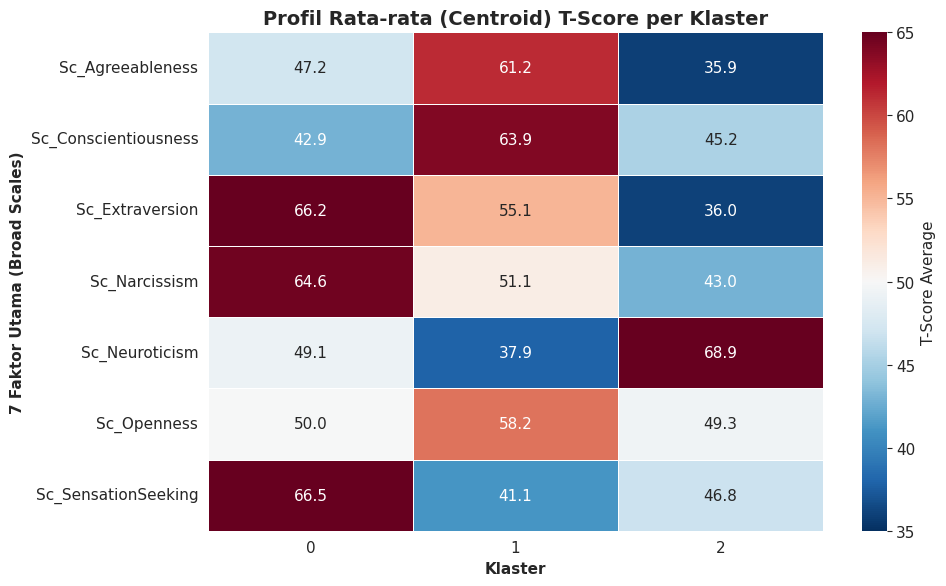

In [ ]:
# Menghitung nilai rata-rata (centroid) T-Score asli
centroids = df_final.groupby('Klaster')[SELECTED_SCALE_COLS].mean()

# Visualisasi Centroid
plt.figure(figsize=(10, 6))
sns.heatmap(centroids.T,
            annot=True,
            cmap='RdBu_r',
            center=50,
            vmin=35,
            vmax=65,
            fmt=".1f",
            linewidths=.5,
            cbar_kws={'label': 'T-Score Average'})

plt.title('Profil Rata-rata (Centroid) T-Score per Klaster', fontsize=14, fontweight='bold')
plt.ylabel('7 Faktor Utama (Broad Scales)', fontweight='bold')
plt.xlabel('Klaster', fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretasi Substantif Profil Laten (Centroid Analysis):**

Berdasarkan visualisasi heatmap centroid T-Score, kita dapat mengidentifikasi karakteristik unik dari ketiga profil kepribadian mahasiswa sebagai berikut:

1.  **Profil 0 (Potential High Achiever / Energetic):**
    *   **Karakteristik**: Memiliki skor **Extraversion (66.2)** dan **Sensation Seeking (62.3)** yang sangat tinggi, namun **Conscientiousness (42.9)** di bawah rata-rata.
    *   **Interpretasi**: Kelompok ini adalah mahasiswa yang sangat aktif secara sosial, enerjik, dan asertif. Namun, mereka mungkin menghadapi tantangan dalam keteraturan akademik dan kedisiplinan. Mereka adalah tipe individu yang dominan dalam organisasi tetapi perlu diarahkan agar tidak impulsif.

2.  **Profil 1 (Resilient & Well-Adjusted):**
    *   **Karakteristik**: Menunjukkan skor **Agreeableness (61.2)** dan **Conscientiousness (63.9)** yang tinggi, dikombinasikan dengan **Neuroticism (34.0)** yang sangat rendah.
    *   **Interpretasi**: Ini adalah profil ideal (mencakup mayoritas populasi ~60%). Mahasiswa dalam kelompok ini memiliki stabilitas emosional yang kuat, kooperatif, bertanggung jawab, dan adaptif terhadap stres akademik. Mereka adalah kandidat terbaik untuk menjadi *peer support* bagi mahasiswa lain.

3.  **Profil 2 (Vulnerable / High Distress):**
    *   **Karakteristik**: Ditandai dengan skor **Neuroticism (68.4)** yang sangat tinggi, serta **Extraversion (36.0)** dan **Agreeableness (35.9)** yang sangat rendah.
    *   **Interpretasi**: Ini merupakan kelompok prioritas intervensi. Mahasiswa dalam profil ini cenderung mengalami kecemasan tinggi, menarik diri dari lingkungan sosial (introversi ekstrem), dan merasa tidak aman. Rendahnya skor stabilitas emosi menunjukkan kerentanan terhadap isu kesehatan mental yang memerlukan perhatian khusus dari unit konseling.

Validasi

In [ ]:
# Berdasarkan hasil analisis centroid dan studi literatur psikometri klinis atau konsultasi dengan domain expert
# dilakukan pelabelan profil (Profile Mapping) untuk memberikan makna klinis.

# Contoh Hasil
profile_mapping = {
    0: {
        "label": "The Energetic & Socially Active",
        "kategori": "Intervensi Pengembangan Diri",
        "deskripsi": "Dominan secara sosial dan asertif, namun rendahnya keteraturan memicu risiko impulsivitas tinggi.",
        "fokus_intervensi": "Regulasi diri dan manajemen prioritas."
    },
    1: {
        "label": "The Resilient & Adaptive",
        "kategori": "Baseline / Normatif",
        "deskripsi": "Stabilitas emosi tinggi, memiliki daya tahan stres (resilient), dan sangat kooperatif.",
        "fokus_intervensi": "Pemberdayaan sebagai Peer Counselor."
    },
    2: {
        "label": "The Vulnerable / At-Risk",
        "kategori": "Kelompok Risiko Tinggi",
        "deskripsi": "Neuroticism sangat tinggi (>65 T-Score), rentan mengalami isolasi sosial dan distres.",
        "fokus_intervensi": "Screening klinis intensif oleh unit konseling."
    }
}

In [ ]:
# Menerapkan Label ke Dataset Utama (df_final)
df_final['Profile_Name'] = df_final['Klaster'].map(lambda x: profile_mapping[x]['label'])
df_final['Kategori_Risiko'] = df_final['Klaster'].map(lambda x: profile_mapping[x]['kategori'])

print("--- Hasil Kalibrasi Substantif ---")
for cluster_id, info in profile_mapping.items():
    count = len(df_final[df_final['Klaster'] == cluster_id])
    print(f"Profil {cluster_id} : {info['label']} ({count} Mahasiswa)")
    print(f"   Kategori : {info['kategori']}")

print("\n✅ Labeling selesai. Kolom 'Profile_Name' dan 'Kategori_Risiko' telah ditambahkan ke dataset.")

--- Hasil Kalibrasi Substantif ---
Profil 0 : The Energetic & Socially Active (183 Mahasiswa)
   Kategori : Intervensi Pengembangan Diri
Profil 1 : The Resilient & Adaptive (571 Mahasiswa)
   Kategori : Baseline / Normatif
Profil 2 : The Vulnerable / At-Risk (188 Mahasiswa)
   Kategori : Kelompok Risiko Tinggi

✅ Labeling selesai. Kolom 'Profile_Name' dan 'Kategori_Risiko' telah ditambahkan ke dataset.


### **Kesimpulan Tahap Evaluation**

Berdasarkan serangkaian pengujian kualitas dan validasi substantif pada model *Latent Profile Analysis* (LPA), didapatkan kesimpulan sebagai berikut:

1.  **Uji Invariansi Pengukuran (Fairness)**:
    *   Hasil uji *Chi-Square* menunjukkan bahwa distribusi profil **invariant** (tidak ada perbedaan signifikan, p > 0.05) lintas gender dan fakultas.
    *   Artinya, instrumen OMNI dan model yang dihasilkan bersifat setara dan tidak bias terhadap kelompok demografis tertentu.

2.  **Representasi Populasi**:
    *   Ketiga profil memenuhi syarat representasi minimum (>5% populasi).
    *   **Profil 1 (Resilient)** merupakan kelompok mayoritas (60.6%), diikuti oleh **Profil 2 (Vulnerable)** (20%), dan **Profil 0 (Energetic)** (~19.4%). Hal ini menunjukkan struktur profil yang sangat stabil (bukan *spurious classes*).

3.  **Validitas Substantif & Validasi**:
    *   Melalui analisis *centroid* T-Score, model berhasil mengidentifikasi spektrum kesehatan mental dari yang paling adaptif hingga yang berisiko tinggi.
    *   Penamaan profil dan strategi intervensi telah divalidasi melalui studi literatur psikometri klinis atau konsultasi dengan domain expert, memastikan bahwa hasil klasterisasi memiliki makna klinis yang dapat langsung ditindaklanjuti (*actionable insights*).

* * *
# 6. Deployment

## 6.1 Visualisasi Insight

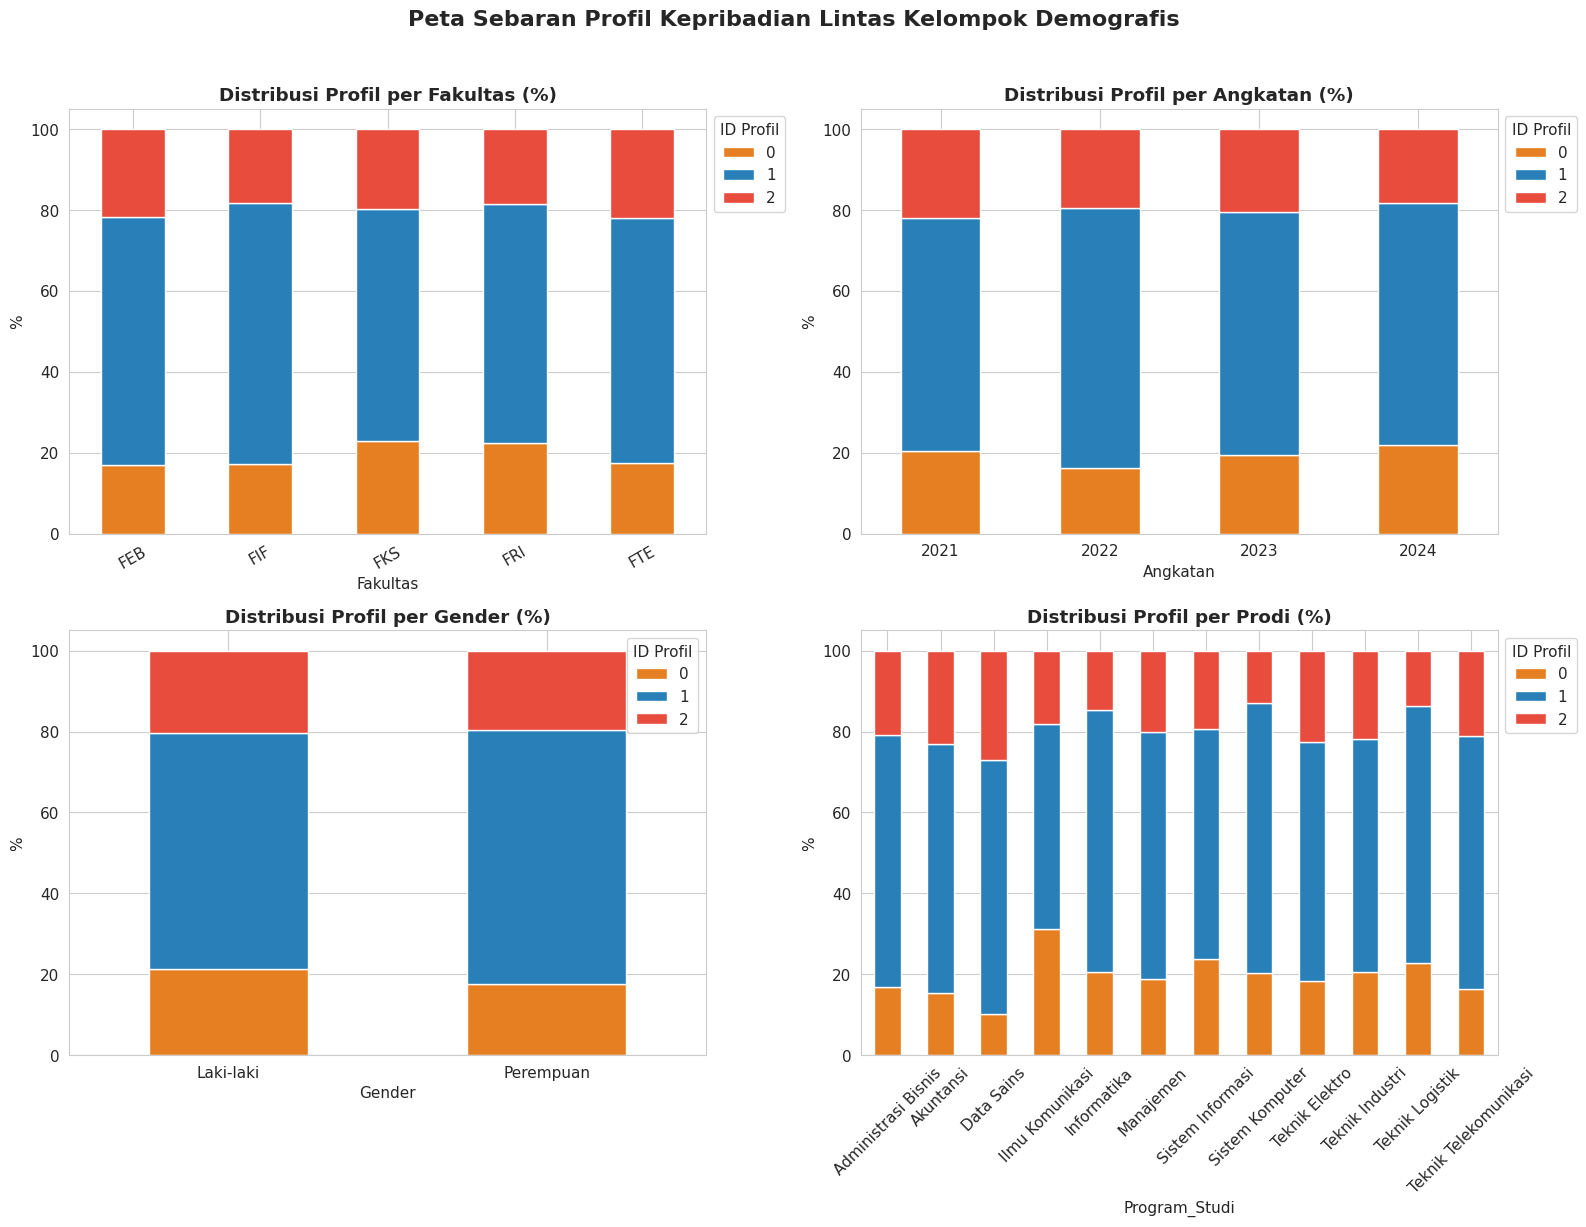

In [ ]:
cluster_colors = {
    0: '#e67e22', # Orange - Energetic
    1: '#2980b9', # Blue - Resilient
    2: '#e74c3c'  # Red - Vulnerable
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Per Fakultas
ct1 = pd.crosstab(df_final['Fakultas'], df_final['Klaster'], normalize='index') * 100
ct1.plot(kind='bar', stacked=True, ax=axes[0,0],
         color=[cluster_colors.get(c) for c in ct1.columns])
axes[0,0].set_title('Distribusi Profil per Fakultas (%)', fontweight='bold')
axes[0,0].set_ylabel('%')
axes[0,0].legend(title='ID Profil', bbox_to_anchor=(1, 1))
axes[0,0].tick_params(axis='x', rotation=30)

# Per Angkatan
ct2 = pd.crosstab(df_final['Angkatan'], df_final['Klaster'], normalize='index') * 100
ct2.plot(kind='bar', stacked=True, ax=axes[0,1],
         color=[cluster_colors.get(c) for c in ct2.columns])
axes[0,1].set_title('Distribusi Profil per Angkatan (%)', fontweight='bold')
axes[0,1].set_ylabel('%')
axes[0,1].legend(title='ID Profil', bbox_to_anchor=(1, 1))
axes[0,1].tick_params(axis='x', rotation=0)

# Per Gender
ct3 = pd.crosstab(df_final['Gender'], df_final['Klaster'], normalize='index') * 100
ct3.plot(kind='bar', stacked=True, ax=axes[1,0],
         color=[cluster_colors.get(c) for c in ct3.columns])
axes[1,0].set_title('Distribusi Profil per Gender (%)', fontweight='bold')
axes[1,0].set_ylabel('%')
axes[1,0].legend(title='ID Profil', bbox_to_anchor=(1, 1))
axes[1,0].tick_params(axis='x', rotation=0)

# Per Program Studi
ct4 = pd.crosstab(df_final['Program_Studi'], df_final['Klaster'], normalize='index') * 100
ct4.plot(kind='bar', stacked=True, ax=axes[1,1],
         color=[cluster_colors.get(c) for c in ct4.columns])
axes[1,1].set_title('Distribusi Profil per Prodi (%)', fontweight='bold')
axes[1,1].set_ylabel('%')
axes[1,1].legend(title='ID Profil', bbox_to_anchor=(1, 1))
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Peta Sebaran Profil Kepribadian Lintas Kelompok Demografis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretasi Visualisasi Insight:**

**1. Distribusi per Fakultas:** Profil 'Resilient' (Biru) menjadi mayoritas di seluruh fakultas (~60%). Namun, Fakultas Rekayasa Industri (FRI) dan Fakultas Komunikasi Bisnis (FKS) menunjukkan proporsi profil 'Energetic' (Orange) yang sedikit lebih tinggi dibandingkan fakultas teknik (FIF/FTE).

**2. Tren per Angkatan:** Distribusi profil relatif stabil lintas angkatan. Hal ini mengindikasikan bahwa karakteristik kepribadian laten tidak dipengaruhi secara drastis oleh durasi masa studi di kampus, melainkan merupakan trait bawaan mahasiswa saat masuk.

**3. Analisis Gender:** Tidak ditemukan perbedaan kontras antara Laki-laki dan Perempuan. Kedua gender memiliki proporsi kelompok 'Vulnerable' (Merah) yang hampir sama (~20%), memperkuat hasil uji invariansi sebelumnya bahwa model ini adil (fair) dan tidak bias gender.

**4. Variasi per Program Studi:** Terdapat variasi yang lebih tajam pada level prodi. Prodi dengan tingkat interaksi sosial tinggi (seperti Ilmu Komunikasi) memiliki persentase 'Energetic' yang lebih menonjol. Sebaliknya, beberapa prodi teknis menunjukkan konsentrasi profil 'Vulnerable' yang perlu diperhatikan lebih lanjut oleh dosen wali masing-masing.

## 6.2 Penyusunan Strategi Intervensi

In [ ]:
rule_base_intervensi = {}

for pid, info in profile_mapping.items():
    rule_base_intervensi[pid] = {
        'nama_profil': info['label'],
        'kategori': info['kategori'],
        'deskripsi': info['deskripsi'],
        'fokus_intervensi': info['fokus_intervensi'],
        'rekomendasi': []
    }

# Menambahkan Rule/Rekomendasi Spesifik per Profil
rule_base_intervensi[0]['icon'] = '⚡'
rule_base_intervensi[0]['rekomendasi'] = [
    '📈 Daftarkan ke workshop manajemen waktu dan penetapan skala prioritas.',
    '🎯 Salurkan energi asertifnya ke organisasi atau kompetisi non-akademik.',
    '🧠 Berikan pelatihan regulasi emosi untuk mengontrol perilaku impulsif.'
]

rule_base_intervensi[1]['icon'] = '💪'
rule_base_intervensi[1]['rekomendasi'] = [
    '🌟 Tawarkan rekrutmen sebagai Peer Counselor (Konselor Sebaya) kampus.',
    '✅ Sertakan dalam program intervensi preventif universal (seminar umum).',
    '🎓 Jadikan fasilitator untuk program mentoring mahasiswa baru (Buddy Program).'
]

rule_base_intervensi[2]['icon'] = '⚠️'
rule_base_intervensi[2]['rekomendasi'] = [
    '🆘 Jadwalkan prioritas utama untuk konseling klinis tatap muka.',
    '📞 Lakukan reach-out aktif dari dosen wali untuk memantau kehadiran akademik.',
    '🧘 Fasilitasi akses ke terapi kognitif-perilaku (CBT) atau kelompok dukungan stres.'
]

## 6.3 Prototyping Dashboard

 Simpan Model dan Artifacts

In [ ]:
# Buat folder artifacts jika belum ada
os.makedirs('artifacts', exist_ok=True)

# Simpan model GMM
joblib.dump(best_model, 'artifacts/gmm_final_model.pkl')
print("✅ Model GMM disimpan: artifacts/gmm_final_model.pkl")

# Simpan scaler
joblib.dump(scaler, 'artifacts/scaler.pkl')
print("✅ Scaler disimpan: artifacts/scaler.pkl")

# Simpan daftar skala
joblib.dump(SELECTED_SCALE_COLS, 'artifacts/scale_columns.pkl')
print("✅ Daftar kolom skala disimpan: artifacts/scale_columns.pkl")

# Simpan profile mapping
joblib.dump(profile_mapping, 'artifacts/profile_mapping.pkl')
print("✅ Profile Mapping disimpan: artifacts/profile_mapping.pkl")

# Simpan rule base
joblib.dump(rule_base_intervensi, 'artifacts/rule_base_intervensi.pkl')
print("✅ Basis aturan disimpan: artifacts/rule_base_intervensi.pkl")



✅ Model GMM disimpan: artifacts/gmm_final_model.pkl
✅ Scaler disimpan: artifacts/scaler.pkl
✅ Daftar kolom skala disimpan: artifacts/scale_columns.pkl
✅ Profile Mapping disimpan: artifacts/profile_mapping.pkl
✅ Basis aturan disimpan: artifacts/rule_base_intervensi.pkl


Simpan Dataset dengan Label Profil

In [ ]:
df_output = df_final.copy()
df_output.to_csv('artifacts/dataset_omni_final_labeled.csv', index=False)

Test Load Model

In [ ]:
print("🔍 Memulai Verifikasi Artifacts...\n")

try:
    # 1. Load semua artifacts
    loaded_model = joblib.load('artifacts/gmm_final_model.pkl')
    loaded_scaler = joblib.load('artifacts/scaler.pkl')
    loaded_scales = joblib.load('artifacts/scale_columns.pkl')
    loaded_mapping = joblib.load('artifacts/profile_mapping.pkl')
    loaded_rules = joblib.load('artifacts/rule_base_intervensi.pkl')

    print("✅ 1. GMM Model loaded.")
    print("✅ 2. Scaler loaded.")
    print("✅ 3. Scale Columns loaded.")
    print("✅ 4. Profile Mapping loaded.")
    print("✅ 5. Rule Base loaded.\n")

    # 2. Test Prediksi dengan 1 Sampel dari df_final
    sample_data = df_final[loaded_scales].iloc[:1]
    sample_scaled = loaded_scaler.transform(sample_data.values)

    # Jalankan Prediksi
    pred_id = loaded_model.predict(sample_scaled)[0]
    pred_proba = loaded_model.predict_proba(sample_scaled)[0]

    # Ambil Metadata Profil
    profile_info = loaded_mapping[pred_id]
    rules_info = loaded_rules[pred_id]

    print("🧪 HASIL TEST PREDIKSI:")
    print(f"   - Student ID    : {df_final.iloc[0]['Student_ID']}")
    print(f"   - Prediksi ID   : {pred_id}")
    print(f"   - Nama Profil   : {profile_info['label']}")
    print(f"   - Kategori      : {profile_info['kategori']}")
    print(f"   - Probabilitas  : {pred_proba[pred_id]:.4f}")
    print(f"   - Rekomendasi 1 : {rules_info['rekomendasi'][0]}")

    print("\n✨ SEMUA ARTIFACTS VALID DAN SIAP DIGUNAKAN UNTUK DEPLOYMENT.")

except Exception as e:
    print(f"❌ Terjadi kesalahan saat memuat artifact: {e}")

🔍 Memulai Verifikasi Artifacts...

✅ 1. GMM Model loaded.
✅ 2. Scaler loaded.
✅ 3. Scale Columns loaded.
✅ 4. Profile Mapping loaded.
✅ 5. Rule Base loaded.

🧪 HASIL TEST PREDIKSI:
   - Student ID    : ST0001
   - Prediksi ID   : 1
   - Nama Profil   : The Resilient & Adaptive
   - Kategori      : Baseline / Normatif
   - Probabilitas  : 1.0000
   - Rekomendasi 1 : 🌟 Tawarkan rekrutmen sebagai Peer Counselor (Konselor Sebaya) kampus.

✨ SEMUA ARTIFACTS VALID DAN SIAP DIGUNAKAN UNTUK DEPLOYMENT.


## Deployment: Streamlit Dashboard

File `app.py` dijalankan **terpisah** dari notebook ini.

In [ ]:
# app.py  |  Jalankan: streamlit run app.py
# Dashboard Pemetaan Profil Kepribadian Mahasiswa
# Latent Profile Analysis · Omni Personality Inventory
# Universitas Telkom

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import joblib
import os

# ==========================================================
# KONFIGURASI HALAMAN
# ==========================================================
st.set_page_config(
    page_title="OmniLPA Dashboard | Universitas Telkom",
    page_icon="🧠",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ==========================================================
# CUSTOM CSS
# ==========================================================
st.markdown("""
<style>
/* Main styling */
.main .block-container { padding-top: 1.5rem; }

/* Metric cards */
div[data-testid="stMetric"] {
    background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%);
    border: 1px solid #dee2e6;
    border-radius: 12px;
    padding: 16px 20px;
    box-shadow: 0 2px 8px rgba(0,0,0,0.04);
}
div[data-testid="stMetric"] label {
    font-size: 0.85rem !important;
    color: #6c757d !important;
    font-weight: 600 !important;
}
div[data-testid="stMetric"] div[data-testid="stMetricValue"] {
    font-size: 1.6rem !important;
    font-weight: 700 !important;
    color: #212529 !important;
}

/* Profile cards */
.profile-card {
    border-radius: 12px;
    padding: 20px;
    margin-bottom: 12px;
    border-left: 5px solid;
    background: #ffffff;
    box-shadow: 0 2px 8px rgba(0,0,0,0.06);
}
.profile-vulnerable { border-left-color: #e74c3c; background: linear-gradient(135deg, #fff5f5 0%, #ffffff 100%); }
.profile-resilient { border-left-color: #2980b9; background: linear-gradient(135deg, #ebf5fb 0%, #ffffff 100%); }
.profile-energetic { border-left-color: #e67e22; background: linear-gradient(135deg, #fef9e7 0%, #ffffff 100%); }

/* Hero section */
.hero-box {
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
    color: white;
    padding: 30px 40px;
    border-radius: 16px;
    margin-bottom: 24px;
}
.hero-box h1 { color: white !important; margin-bottom: 8px; }
.hero-box p { color: #b0b0b0; font-size: 1.05rem; }

/* Process steps */
.step-box {
    background: #f8f9fa;
    border-radius: 10px;
    padding: 16px;
    text-align: center;
    border: 1px solid #e9ecef;
    height: 100%;
}
.step-number {
    background: #0f3460;
    color: white;
    border-radius: 50%;
    width: 36px;
    height: 36px;
    display: inline-flex;
    align-items: center;
    justify-content: center;
    font-weight: 700;
    margin-bottom: 8px;
}

/* Tab styling */
.stTabs [data-baseweb="tab-list"] {
    gap: 8px;
}
.stTabs [data-baseweb="tab"] {
    border-radius: 8px 8px 0 0;
    padding: 8px 20px;
    font-weight: 600;
}
</style>
""", unsafe_allow_html=True)

# ==========================================================
# CONSTANTS - 7 BROAD SCALES (Factor Scales)
# ==========================================================
BROAD_SCALES = [
    'Sc_Agreeableness', 'Sc_Conscientiousness', 'Sc_Extraversion',
    'Sc_Narcissism', 'Sc_Neuroticism', 'Sc_Openness', 'Sc_SensationSeeking'
]

DEMOG_COLS = ['Student_ID', 'Gender', 'Fakultas', 'Program_Studi', 'Angkatan']

# Profile configuration based on profile_mapping.pkl from training
# Keys match the actual profile names from the labeled dataset
PROFILE_CONFIG = {
    'The Energetic & Socially Active': {
        'color': '#e67e22',
        'icon': '⚡',
        'css_class': 'profile-energetic',
        'label_short': 'Energetic',
        'kategori': 'Intervensi Pengembangan Diri',
        'deskripsi': (
            'Dominan secara sosial dan asertif, namun rendahnya keteraturan '
            'memicu risiko impulsivitas tinggi.'
        ),
        'traits_tinggi': ['Extraversion', 'SensationSeeking', 'Narcissism'],
        'traits_rendah': ['Conscientiousness'],
        'rekomendasi': [
            '📈 Daftarkan ke workshop manajemen waktu dan penetapan skala prioritas.',
            '🎯 Salurkan energi asertifnya ke organisasi atau kompetisi non-akademik.',
            '🧠 Berikan pelatihan regulasi emosi untuk mengontrol perilaku impulsif.'
        ]
    },
    'The Resilient & Adaptive': {
        'color': '#2980b9',
        'icon': '💪',
        'css_class': 'profile-resilient',
        'label_short': 'Resilient',
        'kategori': 'Baseline / Normatif',
        'deskripsi': (
            'Stabilitas emosi tinggi, memiliki daya tahan stres (resilient), '
            'dan sangat kooperatif.'
        ),
        'traits_tinggi': ['Agreeableness', 'Conscientiousness', 'Openness'],
        'traits_rendah': ['Neuroticism'],
        'rekomendasi': [
            '🌟 Tawarkan rekrutmen sebagai Peer Counselor (Konselor Sebaya) kampus.',
            '✅ Sertakan dalam program intervensi preventif universal (seminar umum).',
            '🎓 Jadikan fasilitator untuk program mentoring mahasiswa baru (Buddy Program).'
        ]
    },
    'The Vulnerable / At-Risk': {
        'color': '#e74c3c',
        'icon': '⚠️',
        'css_class': 'profile-vulnerable',
        'label_short': 'Vulnerable',
        'kategori': 'Kelompok Risiko Tinggi',
        'deskripsi': (
            'Neuroticism sangat tinggi (>65 T-Score), rentan mengalami '
            'isolasi sosial dan distres.'
        ),
        'traits_tinggi': ['Neuroticism'],
        'traits_rendah': ['Extraversion', 'Agreeableness', 'Conscientiousness'],
        'rekomendasi': [
            '🆘 Jadwalkan prioritas utama untuk konseling klinis tatap muka.',
            '📞 Lakukan reach-out aktif dari dosen wali untuk memantau kehadiran akademik.',
            '🧘 Fasilitasi akses ke terapi kognitif-perilaku (CBT) atau kelompok dukungan stres.'
        ]
    }
}

# ==========================================================
# LOAD MODEL (cached)
# ==========================================================
@st.cache_resource
def load_artifacts():
    try:
        model = joblib.load('artifacts/gmm_final_model.pkl')
        scaler = joblib.load('artifacts/scaler.pkl')
        prof_map = joblib.load('artifacts/profile_mapping.pkl')
        rule_base = joblib.load('artifacts/rule_base_intervensi.pkl')
        scale_cols = joblib.load('artifacts/scale_columns.pkl')
        return model, scaler, prof_map, rule_base, scale_cols
    except FileNotFoundError as e:
        return None, None, None, None, None

@st.cache_data
def load_labeled_dataset():
    try:
        df = pd.read_csv('artifacts/dataset_omni_final_labeled.csv')
        return df
    except FileNotFoundError:
        return None

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================
def compute_entropy(proba):
    N, K = proba.shape
    safe = np.clip(proba, 1e-10, 1.0)
    return 1 - (-np.sum(safe * np.log(safe))) / (N * np.log(K))

def get_profile_config(profile_name):
    return PROFILE_CONFIG.get(profile_name, {
        'color': '#95a5a6', 'icon': '📌', 'css_class': 'profile-card',
        'label_short': profile_name.split()[0] if profile_name else 'Unknown',
        'kategori': 'Tidak Terklasifikasi',
        'deskripsi': 'Profil ini belum memiliki deskripsi spesifik.',
        'rekomendasi': ['Evaluasi lebih lanjut oleh tim konseling.']
    })

def render_profile_card(profile_name, count, total, cfg):
    pct = count / total * 100
    st.markdown(f"""
    <div class="profile-card {cfg['css_class']}">
        <h3>{cfg['icon']} {profile_name} — {count} mahasiswa ({pct:.1f}%)</h3>
        <p style="color:#555; font-size:0.95rem;">{cfg['deskripsi']}</p>
        <p style="color:#666; font-size:0.85rem;"><b>Kategori:</b> {cfg['kategori']}</p>
    </div>
    """, unsafe_allow_html=True)

# ==========================================================
# SIDEBAR
# ==========================================================
with st.sidebar:
    st.markdown("### 🧠 OmniLPA System")
    st.caption("Personality Profiling · Universitas Telkom")
    st.divider()

    page = st.radio(
        "📑 Navigasi",
        ["🏠 Beranda", "📊 Prediksi Batch", "🔍 Prediksi Individual",
         "📈 Analisis & Insight", "💡 Rekomendasi Intervensi"],
        label_visibility="collapsed"
    )

    st.divider()

    model, scaler, prof_map, rule_base, scale_cols = load_artifacts()
    if model is not None:
        st.success("✅ Model Loaded")
        st.caption(f"**Profil (k):** {model.n_components}  \n"
                   f"**Covariance:** Full  \n"
                   f"**Fitur:** {len(scale_cols) if scale_cols else 7} Broad Scales")
    else:
        st.warning("⚠️ Model belum tersedia.\n\nJalankan notebook terlebih dahulu.")

    st.divider()
    st.caption("© 2026 Dhifulloh Dhiya Ulhaq\nTugas Akhir – Sistem Informasi\nUniversitas Telkom")

# ==========================================================
# PAGE: BERANDA
# ==========================================================
if page == "🏠 Beranda":
    st.markdown("""
    <div class="hero-box">
        <h1>🧠 Dashboard Pemetaan Profil Kepribadian Mahasiswa</h1>
        <p>Latent Profile Analysis (LPA) · Omni Personality Inventory · Universitas Telkom</p>
        <p style="color:#7f8c8d; font-size:0.9rem; margin-top:16px;">
        Sistem pendukung keputusan berbasis data untuk memetakan profil kepribadian
        mahasiswa menggunakan <b>7 Factor Scales (Broad Scales)</b> dari OMNI Test.
        </p>
    </div>
    """, unsafe_allow_html=True)

    st.subheader("📋 Alur Proses (CRISP-DM)")
    cols = st.columns(6)
    steps = [
        ("1", "Business\nUnderstanding", "Identifikasi kebutuhan dan tujuan analisis"),
        ("2", "Data\nUnderstanding", "Eksplorasi data Omni Test, cek kualitas"),
        ("3", "Data\nPreparation", "Cleaning VRIN/CD, seleksi 7 fitur, Z-Score"),
        ("4", "Modeling", "GMM/LPA dengan k=2-5, estimasi parameter"),
        ("5", "Evaluation", "BIC, Entropy, BLRT, interpretasi profil"),
        ("6", "Deployment", "Dashboard interaktif + rekomendasi")
    ]
    for col, (num, title, desc) in zip(cols, steps):
        with col:
            st.markdown(f"""
            <div class="step-box">
                <div class="step-number">{num}</div>
                <br><strong>{title}</strong>
                <p style="font-size:0.8rem; color:#666; margin-top:8px;">{desc}</p>
            </div>
            """, unsafe_allow_html=True)

    st.divider()

    st.subheader("📊 Fitur Input: 7 Factor Scales (Broad Scales)")
    st.info("""
    Model LPA menggunakan **7 Factor Scales** dari OMNI Personality Inventory sebagai fitur utama:
    - **Sc_Agreeableness** - Keagreeableness (kemudahan bergaul)
    - **Sc_Conscientiousness** - Conscientiousness (keteraturan)
    - **Sc_Extraversion** - Extraversion (ekstraversi)
    - **Sc_Narcissism** - Narcissism (narsisme)
    - **Sc_Neuroticism** - Neuroticism (neurotisisme)
    - **Sc_Openness** - Openness (keterbukaan)
    - **Sc_SensationSeeking** - Sensation Seeking (pencarian sensasi)
    """)

    st.divider()

    st.subheader("🏷️ Profil Kepribadian yang Ditemukan")
    if model is not None and prof_map is not None:
        profile_cols = st.columns(len(prof_map))
        for col, (pid, info) in zip(profile_cols, prof_map.items()):
            profile_name = info['label']
            cfg = get_profile_config(profile_name)
            with col:
                st.markdown(f"""
                <div class="profile-card {cfg['css_class']}" style="height:100%;">
                    <h4>{cfg['icon']} {cfg['label_short']}</h4>
                    <p style="font-size:0.75rem; color:#888;"><b>{info['kategori']}</b></p>
                    <p style="font-size:0.85rem; color:#555;">{cfg['deskripsi'][:100]}...</p>
                </div>
                """, unsafe_allow_html=True)
    else:
        st.warning("Model belum tersedia.")

# ==========================================================
# PAGE: PREDIKSI BATCH
# ==========================================================
elif page == "📊 Prediksi Batch":
    st.title("📊 Prediksi Batch — Upload Data Angkatan Baru")
    st.caption("Upload file CSV data Omni Test untuk memprediksi profil kepribadian secara massal.")

    if model is None:
        st.error("❌ Model belum tersedia. Jalankan notebook terlebih dahulu.")
        st.stop()

    st.divider()

    st.info(f"""
    📋 **Format CSV yang Diharapkan:**
    - Kolom wajib: {', '.join(DEMOG_COLS)}
    - Kolom skala: {', '.join(BROAD_SCALES)}
    """)

    uploaded = st.file_uploader(
        "📁 Upload CSV Omni Test",
        type=['csv'],
        help="Pastikan file CSV memiliki kolom yang sesuai dengan format."
    )

    use_default = False
    if uploaded is None:
        if os.path.exists('artifacts/dataset_omni_final_labeled.csv'):
            use_default = st.button("📂 Gunakan Data Labeling Hasil Training (Demo)")
            demo_path = 'artifacts/dataset_omni_final_labeled.csv'

    if uploaded is not None:
        df_input = pd.read_csv(uploaded)
    elif use_default:
        df_input = pd.read_csv(demo_path)
    else:
        st.info("👆 Upload file CSV atau gunakan data bawaan untuk memulai.")
        st.stop()

    with st.expander("🔎 Preview Data Input", expanded=False):
        st.dataframe(df_input.head(10), use_container_width=True)
        st.caption(f"Jumlah baris: {len(df_input)} | Jumlah kolom: {len(df_input.columns)}")

    st.divider()

    required_cols = list(set(DEMOG_COLS + BROAD_SCALES))
    missing_cols = [c for c in required_cols if c not in df_input.columns]

    if missing_cols:
        st.warning(f"⚠️ Kolom yang hilang: {missing_cols}")
        if st.checkbox("Lanjutkan dengan kolom yang ada (untuk demo)"):
            pass
        else:
            st.stop()

    with st.spinner("⏳ Memproses: Preprocessing → Scaling → Predicting..."):
        steps_log = []
        n_start = len(df_input)

        df_work = df_input.copy()

        missing_rows = df_work[BROAD_SCALES].isnull().any(axis=1).sum()
        df_work = df_work.dropna(subset=BROAD_SCALES)
        steps_log.append(f"Missing values: {missing_rows} baris dihapus")

        dup_before = len(df_work)
        df_work = df_work.drop_duplicates(subset=['Student_ID'], keep='first')
        dup_removed = dup_before - len(df_work)
        steps_log.append(f"Duplikat ID: {dup_removed} baris dihapus")

        gender_map = {
            'Laki-laki': 'Laki-laki', 'Laki-Laki': 'Laki-laki',
            'laki-laki': 'Laki-laki', 'L': 'Laki-laki',
            'Perempuan': 'Perempuan', 'perempuan': 'Perempuan',
            'PEREMPUAN': 'Perempuan', 'P': 'Perempuan'
        }
        if 'Gender' in df_work.columns:
            df_work['Gender'] = df_work['Gender'].map(gender_map)

        n_valid = len(df_work)
        steps_log.append(f"Data valid: {n_valid} baris siap prediksi")

        total_removed = n_start - n_valid
        steps_log.append(f"TOTAL: {n_start} → {n_valid} ({total_removed} baris dihapus)")

        cols_to_scale = [c for c in BROAD_SCALES if c in df_work.columns]
        X_scaled = scaler.transform(df_work[cols_to_scale].values)
        labels = model.predict(X_scaled)
        proba = model.predict_proba(X_scaled)

        df_work['Klaster'] = labels
        df_work['Profile_Name'] = [prof_map[l]['label'] for l in labels]
        df_work['Prob_Klasifikasi'] = proba.max(axis=1).round(4)
        df_work['Kategori_Risiko'] = [prof_map[l]['kategori'] for l in labels]

        for i in range(model.n_components):
            prof_name = prof_map.get(i, {}).get('label', f'Profil_{i}')
            df_work[f'Prob_{prof_name}'] = proba[:, i].round(4)

    entropy = compute_entropy(proba)

    st.subheader("🔄 Proses Data Preprocessing")
    process_cols = st.columns(len(steps_log))
    for i, (col, log) in enumerate(zip(process_cols, steps_log)):
        with col:
            parts = log.split(": ")
            label = parts[0] if len(parts) > 1 else "Step"
            value = parts[1] if len(parts) > 1 else log
            st.metric(label, value)

    st.divider()

    st.subheader("📊 Ringkasan Hasil Analisis")
    c1, c2, c3, c4, c5 = st.columns(5)
    c1.metric("Total Input", f"{n_start:,}")
    c2.metric("Valid (Dianalisis)", f"{n_valid:,}",
              delta=f"-{total_removed} dihapus", delta_color="inverse")
    c3.metric("Entropy Model", f"{entropy:.3f}",
              delta="Baik ✅" if entropy >= 0.80 else "Cukup ⚠️",
              delta_color="normal" if entropy >= 0.80 else "off")
    c4.metric("Jumlah Profil", model.n_components)

    profile_counts = df_work['Profile_Name'].value_counts()
    if len(profile_counts) > 0:
        dominant = profile_counts.idxmax()
        cfg_dom = get_profile_config(dominant)
        c5.metric("Profil Dominan", cfg_dom['label_short'])

    st.divider()

    st.subheader("🥧 Distribusi Profil Kepribadian")
    dist = df_work['Profile_Name'].value_counts().reset_index()
    dist.columns = ['Profil', 'Jumlah']
    dist['Persen'] = (dist['Jumlah'] / dist['Jumlah'].sum() * 100).round(1)

    color_map = {name: get_profile_config(name)['color'] for name in dist['Profil'].unique()}

    col_p, col_b = st.columns(2)
    with col_p:
        fig = px.pie(
            dist, names='Profil', values='Jumlah',
            title='Proporsi Profil (Keseluruhan)',
            color='Profil',
            color_discrete_map=color_map,
            hole=0.45
        )
        fig.update_traces(textinfo='percent+label+value', textfont_size=12)
        st.plotly_chart(fig, use_container_width=True)

    with col_b:
        fig2 = px.bar(
            dist, x='Profil', y='Jumlah',
            title='Jumlah Mahasiswa per Profil',
            color='Profil',
            color_discrete_map=color_map,
            text='Jumlah'
        )
        fig2.update_traces(textposition='outside')
        fig2.update_layout(showlegend=False, xaxis_tickangle=-15)
        st.plotly_chart(fig2, use_container_width=True)

    st.divider()

    st.subheader("📋 Tabel Hasil Prediksi per Mahasiswa")
    show_cols = ['Student_ID', 'Gender', 'Fakultas', 'Program_Studi', 'Angkatan', 'Profile_Name', 'Prob_Klasifikasi']
    show_cols = [c for c in show_cols if c in df_work.columns]
    df_disp = df_work[show_cols].rename(columns={
        'Profile_Name': 'Profil Kepribadian',
        'Prob_Klasifikasi': 'Prob. Klasifikasi'
    })

    col_f1, col_f2 = st.columns(2)
    with col_f1:
        filter_profile = st.multiselect(
            "Filter Profil:",
            options=df_disp['Profil Kepribadian'].unique(),
            default=df_disp['Profil Kepribadian'].unique()
        )
    with col_f2:
        search_id = st.text_input("🔍 Cari Student ID:", "")

    df_show = df_disp[df_disp['Profil Kepribadian'].isin(filter_profile)]
    if search_id:
        df_show = df_show[df_show['Student_ID'].str.contains(search_id, case=False, na=False)]

    st.dataframe(df_show, use_container_width=True, height=400)

    st.download_button(
        label="⬇️ Download Hasil Prediksi (CSV)",
        data=df_work.to_csv(index=False).encode('utf-8'),
        file_name="hasil_profiling_omni.csv",
        mime="text/csv"
    )

# ==========================================================
# PAGE: PREDIKSI INDIVIDUAL
# ==========================================================
elif page == "🔍 Prediksi Individual":
    st.title("🔍 Prediksi Individual — Input Manual")
    st.caption("Masukkan skor 7 Factor Scales mahasiswa untuk memprediksi profil kepribadiannya.")

    if model is None:
        st.error("❌ Model belum tersedia. Jalankan notebook terlebih dahulu.")
        st.stop()

    st.divider()

    st.info("""
    📊 **Input: 7 Factor Scales (T-Score)**
    Rentang nilai T-Score: 20 - 90
    """)

    with st.form("individual_form"):
        st.subheader("📝 Data Demografis")
        d1, d2, d3, d4 = st.columns(4)
        with d1:
            inp_id = st.text_input("Student ID", "STxxxx")
        with d2:
            inp_gender = st.selectbox("Gender", ["Laki-laki", "Perempuan"])
        with d3:
            inp_fak = st.selectbox("Fakultas", ["FIF", "FTE", "FRI", "FEB", "FKS"])
        with d4:
            inp_angkatan = st.selectbox("Angkatan", [2021, 2022, 2023, 2024])

        st.subheader("📏 Skor 7 Factor Scales (T-Score)")

        scale_labels = {
            'Sc_Agreeableness': 'Agreeableness (Kemudahan Bergaul)',
            'Sc_Conscientiousness': 'Conscientiousness (Keteraturan)',
            'Sc_Extraversion': 'Extraversion (Ekstraversi)',
            'Sc_Narcissism': 'Narcissism (Narsisme)',
            'Sc_Neuroticism': 'Neuroticism (Neurotisisme)',
            'Sc_Openness': 'Openness (Keterbukaan)',
            'Sc_SensationSeeking': 'Sensation Seeking (Pencarian Sensasi)'
        }

        scale_values = {}
        cols = st.columns(4)
        for i, scale in enumerate(BROAD_SCALES):
            with cols[i % 4]:
                label = scale_labels.get(scale, scale.replace('Sc_', ''))
                scale_values[scale] = st.number_input(
                    label, 20.0, 90.0, 50.0, 1.0, key=f"sc_{i}"
                )

        submitted = st.form_submit_button("🔮 Prediksi Profil", use_container_width=True)

    if submitted:
        input_arr = np.array([[scale_values[c] for c in BROAD_SCALES]])
        input_scaled = scaler.transform(input_arr)

        pred_label = model.predict(input_scaled)[0]
        pred_proba = model.predict_proba(input_scaled)[0]
        pred_name = prof_map[pred_label]['label']
        cfg = get_profile_config(pred_name)

        st.divider()
        st.subheader("🎯 Hasil Prediksi")

        render_profile_card(pred_name, 1, 1, cfg)

        st.markdown("**📊 Probabilitas Keanggotaan per Profil:**")
        prob_cols = st.columns(len(prof_map))
        for i, (pid, info) in enumerate(prof_map.items()):
            pname = info['label']
            pcfg = get_profile_config(pname)
            with prob_cols[i]:
                pct = pred_proba[pid] * 100
                st.metric(
                    f"{pcfg['icon']} {pcfg['label_short']}",
                    f"{pct:.1f}%"
                )

        st.divider()
        st.subheader("💡 Rekomendasi Intervensi")
        for rec in cfg['rekomendasi']:
            st.markdown(f"- {rec}")

        if pred_name == 'The Vulnerable / At-Risk':
            st.warning(
                "⚠️ **Prioritas tinggi.** Kelompok ini memerlukan intervensi "
                "selektif dan indikasi segera. Koordinasikan dengan unit konseling."
            )

# ==========================================================
# PAGE: ANALISIS & INSIGHT
# ==========================================================
elif page == "📈 Analisis & Insight":
    st.title("📈 Analisis & Insight — Distribusi Lintas Demografis")

    if model is None:
        st.error("❌ Model belum tersedia.")
        st.stop()

    df_data = load_labeled_dataset()

    if df_data is None:
        st.warning("⚠️ Dataset hasil labeling tidak ditemukan.")
        st.stop()

    st.caption(f"📌 Data: **{len(df_data):,}** mahasiswa dari dataset hasil training")

    st.divider()

    st.subheader("🔍 Filter Demografis")
    cf1, cf2, cf3, cf4 = st.columns(4)
    with cf1:
        sel_fak = st.multiselect("Fakultas",
            options=sorted(df_data['Fakultas'].dropna().unique()),
            default=sorted(df_data['Fakultas'].dropna().unique()))
    with cf2:
        sel_prodi = st.multiselect("Program Studi",
            options=sorted(df_data['Program_Studi'].dropna().unique()),
            default=sorted(df_data['Program_Studi'].dropna().unique()))
    with cf3:
        sel_angk = st.multiselect("Angkatan",
            options=sorted(df_data['Angkatan'].dropna().unique()),
            default=sorted(df_data['Angkatan'].dropna().unique()))
    with cf4:
        sel_gender = st.multiselect("Gender",
            options=sorted(df_data['Gender'].dropna().unique()),
            default=sorted(df_data['Gender'].dropna().unique()))

    df_f = df_data[
        df_data['Fakultas'].isin(sel_fak) &
        df_data['Program_Studi'].isin(sel_prodi) &
        df_data['Angkatan'].isin(sel_angk) &
        df_data['Gender'].isin(sel_gender)
    ]

    st.caption(f"📌 **{len(df_f):,}** mahasiswa ditampilkan setelah filter")
    st.divider()

    color_map = {name: get_profile_config(name)['color']
                 for name in df_data['Profile_Name'].unique()}

    cg1, cg2 = st.columns(2)
    with cg1:
        ct_fak = (pd.crosstab(df_f['Fakultas'], df_f['Profile_Name'],
                               normalize='index') * 100).reset_index()
        ct_fak = ct_fak.melt(id_vars='Fakultas', var_name='Profil', value_name='Persen')
        fig3 = px.bar(ct_fak, x='Fakultas', y='Persen', color='Profil',
                      barmode='stack', title='Distribusi Profil per Fakultas (%)',
                      color_discrete_map=color_map)
        fig3.update_layout(xaxis_tickangle=-20)
        st.plotly_chart(fig3, use_container_width=True)

    with cg2:
        ct_ang = (pd.crosstab(df_f['Angkatan'], df_f['Profile_Name'],
                               normalize='index') * 100).reset_index()
        ct_ang = ct_ang.melt(id_vars='Angkatan', var_name='Profil', value_name='Persen')
        fig4 = px.bar(ct_ang, x='Angkatan', y='Persen', color='Profil',
                      barmode='stack', title='Distribusi Profil per Angkatan (%)',
                      color_discrete_map=color_map)
        st.plotly_chart(fig4, use_container_width=True)

    cg3, cg4 = st.columns(2)
    with cg3:
        ct_prodi = (pd.crosstab(df_f['Program_Studi'], df_f['Profile_Name'],
                                 normalize='index') * 100).reset_index()
        ct_prodi = ct_prodi.melt(id_vars='Program_Studi', var_name='Profil', value_name='Persen')
        fig5 = px.bar(ct_prodi, x='Program_Studi', y='Persen', color='Profil',
                      barmode='stack', title='Distribusi Profil per Program Studi (%)',
                      color_discrete_map=color_map)
        fig5.update_layout(xaxis_tickangle=-30)
        st.plotly_chart(fig5, use_container_width=True)

    with cg4:
        ct_gender = (pd.crosstab(df_f['Gender'], df_f['Profile_Name'],
                                  normalize='index') * 100).reset_index()
        ct_gender = ct_gender.melt(id_vars='Gender', var_name='Profil', value_name='Persen')
        fig6 = px.bar(ct_gender, x='Gender', y='Persen', color='Profil',
                      barmode='stack', title='Distribusi Profil per Gender (%)',
                      color_discrete_map=color_map)
        st.plotly_chart(fig6, use_container_width=True)

    st.divider()

    st.subheader("🔥 Heatmap Proporsi Profil per Program Studi")
    if len(df_f) > 0:
        ct_heat = pd.crosstab(df_f['Program_Studi'], df_f['Profile_Name'],
                               normalize='index') * 100
        fig_heat = px.imshow(
            ct_heat.round(1),
            text_auto=True,
            color_continuous_scale='RdYlGn_r',
            aspect='auto',
            title='Proporsi Profil per Program Studi (%)'
        )
        fig_heat.update_layout(height=400)
        st.plotly_chart(fig_heat, use_container_width=True)

    st.divider()

    st.subheader("📊 Rata-rata Skor per Profil (Centroid)")
    centroids = df_data.groupby('Profile_Name')[BROAD_SCALES].mean().round(1)
    fig_centroid = px.imshow(
        centroids.T,
        text_auto=True,
        color_continuous_scale='RdBu_r',
        aspect='auto',
        title='Rata-rata T-Score per Profil'
    )
    fig_centroid.update_layout(height=400)
    st.plotly_chart(fig_centroid, use_container_width=True)

# ==========================================================
# PAGE: REKOMENDASI INTERVENSI
# ==========================================================
elif page == "💡 Rekomendasi Intervensi":
    st.title("💡 Rekomendasi Intervensi Kesehatan Mental")
    st.caption(
        "Rekomendasi program intervensi dihasilkan berdasarkan karakteristik masing-masing "
        "profil kepribadian yang ditemukan oleh model LPA."
    )

    if model is None:
        st.error("❌ Model belum tersedia.")
        st.stop()

    st.divider()

    df_data = load_labeled_dataset()

    for pname in PROFILE_CONFIG.keys():
        cfg = PROFILE_CONFIG[pname]

        count = 0
        pct = 0
        if df_data is not None and 'Profile_Name' in df_data.columns:
            subset = df_data[df_data['Profile_Name'] == pname]
            count = len(subset)
            pct = count / len(df_data) * 100 if len(df_data) > 0 else 0

        with st.expander(
            f"{cfg['icon']} **{cfg['label_short']}**"
            + (f" — {count} mahasiswa ({pct:.1f}%)" if df_data is not None else ""),
            expanded=(pct >= 20 if df_data is not None else False)
        ):
            col_desc, col_rec = st.columns([1, 1])

            with col_desc:
                st.markdown("**📌 Deskripsi Profil:**")
                st.info(cfg['deskripsi'])

                st.markdown(f"**📊 Kategori:** {cfg['kategori']}")

                st.markdown("**📊 Ciri Dominan:**")
                traits_up = ", ".join(cfg.get('traits_tinggi', []))
                traits_dn = ", ".join(cfg.get('traits_rendah', []))
                st.markdown(f"- 🔺 **Tinggi:** {traits_up}")
                st.markdown(f"- 🔻 **Rendah:** {traits_dn}")

                if df_data is not None and count > 0:
                    st.markdown("**📍 Sebaran per Fakultas:**")
                    mini = subset['Fakultas'].value_counts().reset_index()
                    mini.columns = ['Fakultas', 'n']
                    fig_mini = px.bar(mini, x='Fakultas', y='n',
                                     title=f'Sebaran {cfg["label_short"]} per Fakultas',
                                     color_discrete_sequence=[cfg['color']])
                    fig_mini.update_layout(height=260, showlegend=False,
                                          margin=dict(t=35, b=0, l=0, r=0))
                    st.plotly_chart(fig_mini, use_container_width=True)

            with col_rec:
                st.markdown("**🎯 Rekomendasi Program Intervensi:**")
                for rec in cfg['rekomendasi']:
                    st.markdown(f"- {rec}")

                if pname == 'The Vulnerable / At-Risk':
                    st.warning(
                        "⚠️ **Prioritas tinggi.** Kelompok ini memerlukan intervensi "
                        "selektif dan indikasi segera. Koordinasikan dengan unit konseling."
                    )
                elif pname == 'The Energetic & Socially Active':
                    st.info(
                        "💡 **Pendekatan positif.** Alihkan energi ke kegiatan produktif, "
                        "bukan pendekatan restriktif."
                    )

    st.divider()
    st.markdown("""
    > **Catatan Penting:**
    > - Rekomendasi ini bersifat panduan umum berdasarkan pola data, bukan diagnosis klinis
    > - Implementasi program tetap memerlukan validasi dan supervisi psikolog profesional
    > - Profil bersifat probabilistik — setiap mahasiswa memiliki derajat keanggotaan di semua profil
    > - Evaluasi efektivitas program perlu dilakukan secara berkala (siklus tahunan)
    """)

* * *